# kin_06 — Lick geometry and choice

**Does the direction of a preparatory tongue movement predict which spout the animal
goes on to lick?**

`kin_01` and `kin_03` carry `endpoint_x/y`, `excursion_angle_deg` and the
`max_*_from_jaw` columns, but never place them in the anatomical frame (jaw and spouts)
that makes them interpretable, and never ask what that frame sets up. `kin_05` shows that
a large fraction of tongue movements trigger no lickometer contact, and that such
movements often precede the trial's cue-response lick. This notebook asks whether those
pre-lick movements already point at the spout the animal is about to choose.

The landmark figures (§3-§4) are the **setup**; the choice decode (§7-§8) is the
**result**.

**Pipeline:**
1. Load the pooled `all_tongue_movements` parquet and recover a per-session jaw origin
2. The landmark frame: jaw and spout positions, jaw↔spout scale *(Code Ocean only)*
3. Cue-response endpoints by lick side, over the landmarks *(Code Ocean only)*
4. Lick vs. non-lick excursion geometry, pooled in the jaw-centered frame
5. Non-lick endpoints by movement ordinal within trial
6. Does pre-lick direction predict choice? Excursion angle by subsequent lick side;
   binned P(right lick)
7. Ridge-logistic decode of lick side from last-pre-lick kinematics, with session as the
   grouping unit, a shuffled-label null, and the recent-choice confound quantified
8. Pre-lick → cue-response endpoint displacement, per trial

**Local vs Code Ocean**
- Local: §2 and §5-§9 run on the pooled parquet.
- Code Ocean: additionally §3-§4, which need per-session keypoint means
  (`kps_raw_*.parquet`) for the **absolute** spout positions. Those are not in the
  pooled parquet, so both sections print a skip message locally.

## 1. Setup

In [24]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.inspection import permutation_importance

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()


def fmt_p(pvalue, floor=1e-300):
    """Format a p-value, reporting underflow as a bound instead of "0".

    SciPy returns exactly 0.0 when a p-value underflows double precision,
    which reads as a computed zero. This prints the bound instead.

    Parameters
    ----------
    pvalue : float
        p-value to format.
    floor : float
        Smallest value printed literally; anything below is shown as "< floor".

    Returns
    -------
    str
        Formatted p-value.
    """
    return "< {:.0e}".format(floor) if pvalue < floor else "= {:.3g}".format(pvalue)

In [25]:
if Path("/root/capsule").exists():
    ENV       = "codeocean"
    SCRATCH   = Path("/root/capsule/scratch")
    FOR_LOCAL = SCRATCH / "for_local"
else:
    ENV       = "local"
    FOR_LOCAL = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local")
    SCRATCH   = FOR_LOCAL.parent

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "kin_06_lick_geometry_choice"
SAVE_FIG = False

# Per-session intermediate data (Code Ocean only) — same asset kin_00 / kin_05 use.
SESSION_DIR = SCRATCH / "session_analysis_mlk"

# Lick side is encoded in the `event` column; one color per side, used everywhere below.
SIDE_COLOR = {"left_lick_time": PALETTE["neg"], "right_lick_time": PALETTE["pos"]}
SIDE_LABEL = {"left_lick_time": "Left lick", "right_lick_time": "Right lick"}
print("ENV={}".format(ENV))

ENV=codeocean


## 2. Load data

In [26]:
if ENV == "codeocean":
    movements_path = SCRATCH / "all_tongue_movements_04022026" / "all_tongue_movements_04022026.parquet"
else:
    movements_path = FOR_LOCAL / "all_tongue_movements_04022026.parquet"

all_tongue_movements = pd.read_parquet(movements_path)
print("Shape:", all_tongue_movements.shape)
print("Sessions:", all_tongue_movements["session"].nunique())


def coerce_bool(series):
    """Coerce an object-dtype True/False/None column to real booleans.

    Plain ``astype(bool)`` on an object column turns any non-empty string
    (including the string "False") into True. This instead treats only
    True/1/"True" as true and everything else, including None, as false.

    Parameters
    ----------
    series : pandas.Series
        Object-dtype column holding True/False/None (or their 1/0/string
        equivalents).

    Returns
    -------
    pandas.Series
        Boolean-dtype series.
    """
    return series.isin([True, 1, "True"])


df = all_tongue_movements.copy()
df["cue_response"] = coerce_bool(df["cue_response"])
# has_lick is already real bool. movement_before_cue_response is pandas nullable
# "boolean" (True/False/<NA>); comparisons below use `== True` so <NA> stays excluded.
print("\nCue-response movements:", int(df["cue_response"].sum()))
print(df.loc[df["cue_response"], "event"].value_counts(dropna=False).to_string())

Shape: (246359, 49)
Sessions: 44

Cue-response movements: 16029
event
left_lick_time     8873
right_lick_time    7156


### 2.1 Recovering the jaw origin — and a correction to the column naming

`max_x_from_jaw` / `max_y_from_jaw` sound jaw-relative. **They are not.** They are the
*absolute* pixel coordinates of the point on the trajectory that is farthest from the jaw
in x (resp. y); the jaw-relative *distances* live in `max_x_distance` / `max_y_distance`.
The pooled means make this immediate — `max_x_from_jaw` averages ~368 px while
`max_x_distance` averages ~25 px.

This matters for pooling. `endpoint_x/y` and the `max_*_from_jaw` columns are all in raw
camera pixels, so each session carries its own jaw/camera offset: per-session mean
`endpoint_y` ranges over ~80 px across the 44 sessions, against a within-session SD of
~51 px. Pooling them raw would smear the anatomical frame that the whole notebook depends
on. (`TODO.md`'s data-availability note says these columns are "jaw-relative and therefore
pooled-safe" — that is wrong, and is corrected here.)

**Preferred source: the real jaw keypoint.** Every session's `kps_raw_jaw.parquet`
(`intermediate_data/`, same asset §3's landmarks use) carries the tracked jaw position
per frame; its mean is the actual jaw location, no reconstruction needed. This is Code
Ocean only, so it is not available in this local run — but the notebook is written to use
it whenever it can, session by session, rather than only for the one example session §3
plots.

**Fallback when the keypoint file isn't available (i.e., always, locally):** the jaw
position is still recoverable from the pooled parquet itself, algebraically, because the
distance columns are the absolute columns minus the (constant, per-session) jaw
coordinate:

- `jaw_x = median(max_x_from_jaw - max_x_distance)` — the tongue protrudes in +x, so the
  minus branch is the correct one (its within-session SD is ~4 px vs ~20 px for the plus
  branch).
- `jaw_y` has no fixed sign, since the tongue goes to either spout. Each row gives *two*
  candidates, `max_y_from_jaw ± max_y_distance`, one of which is the true `jaw_y`. A 1-D
  search for the value minimizing the median distance to the nearer candidate recovers it.

**What the fallback's fit-quality number does and doesn't show.** Its reported residual is
the median distance from the fitted `jaw_y` to the *nearer* of each row's own two
candidates — an internal self-consistency check confirming the two-branch structure is
clean, not a comparison to the true jaw position. `jaw_x` is exact up to tracking noise
(one candidate per row, not two), so it needs no such check. `jaw_y` could still be biased
(e.g. if excursions are systematically farther to one spout than the other, the grid search
would settle off-center) — that failure mode is invisible to this residual.

`get_jaw_positions()` below tries the keypoint file for every session first and only falls
back to the algebraic reconstruction where it's missing, then — for whichever sessions
have *both* — reports how far apart the two methods land. That comparison is the real
validation of the fallback, run automatically across every available session rather than
deferred to a single example. In this local run it can't run (no `kps_raw_*.parquet`
exists in `data/for_local/`), so all 44 sessions use the fallback and `jaw_y` stays
unverified here; on Code Ocean, expect most or all sessions to resolve to real keypoints
instead.

Everything downstream uses the resulting `*_rel` columns (jaw at the origin, +y toward the
right spout).

In [27]:
def estimate_jaw_position(movements, y_step=0.5):
    """Recover each session's jaw position from movement-level columns, algebraically.

    Fallback for when the real jaw keypoint isn't available (see
    ``load_jaw_from_keypoints`` / ``get_jaw_positions``, which prefer it). The
    pooled parquet stores absolute coordinates (``max_x_from_jaw``,
    ``max_y_from_jaw``) alongside their unsigned distances from the jaw
    (``max_x_distance``, ``max_y_distance``). Since the jaw position is a
    per-session constant, it can be solved for without the keypoint tables.

    Parameters
    ----------
    movements : pandas.DataFrame
        Movement-level table with a ``session`` column plus
        ``max_x_from_jaw``, ``max_x_distance``, ``max_y_from_jaw`` and
        ``max_y_distance``.
    y_step : float
        Grid resolution, in pixels, of the 1-D search for ``jaw_y``.

    Returns
    -------
    pandas.DataFrame
        Indexed by session, with columns ``jaw_x``, ``jaw_y`` and
        ``jaw_y_resid`` (median absolute distance from the fitted ``jaw_y`` to
        the nearer of each row's two candidates). This is an **internal
        self-consistency check only** — it confirms the two-candidate structure
        is clean, not that ``jaw_y`` matches the true jaw keypoint. It cannot
        detect a systematic offset (e.g. excursions skewed toward one spout).
        ``get_jaw_positions`` is where this gets checked against the real thing.
    """
    rows = []
    for session, grp in movements.groupby("session"):
        # x: the tongue protrudes in +x, so jaw_x is the minus branch.
        jaw_x = np.median(grp["max_x_from_jaw"] - grp["max_x_distance"])

        # y: sign varies with lick side, so search for the value consistent with
        # one of the two candidates in as many rows as possible.
        lo = (grp["max_y_from_jaw"] - grp["max_y_distance"]).values
        hi = (grp["max_y_from_jaw"] + grp["max_y_distance"]).values
        grid = np.arange(min(lo.min(), hi.min()), max(lo.max(), hi.max()), y_step)
        cost = np.array([np.median(np.minimum(np.abs(lo - v), np.abs(hi - v))) for v in grid])
        k = int(cost.argmin())
        rows.append((session, jaw_x, grid[k], cost[k]))

    return pd.DataFrame(rows, columns=["session", "jaw_x", "jaw_y", "jaw_y_resid"]).set_index("session")


def load_jaw_from_keypoints(session, session_dir=None):
    """Read a session's real jaw position from its keypoint parquet, if present.

    Parameters
    ----------
    session : str
        Session id, matching the subdirectory name under ``session_dir``.
    session_dir : pathlib.Path, optional
        Root holding one subdirectory per session, each with
        ``intermediate_data/kps_raw_jaw.parquet``. Defaults to the
        notebook-level ``SESSION_DIR``.

    Returns
    -------
    tuple of (float, float), or None
        ``(jaw_x, jaw_y)`` as the keypoint's mean position across the session,
        or None if the file doesn't exist (e.g. running locally, or an
        unprocessed session).
    """
    session_dir = SESSION_DIR if session_dir is None else session_dir
    kps_path = session_dir / session / "intermediate_data" / "kps_raw_jaw.parquet"
    if not kps_path.exists():
        return None
    kps_jaw = pd.read_parquet(kps_path)
    return float(kps_jaw["x"].mean()), float(kps_jaw["y"].mean())


def get_jaw_positions(movements):
    """Get each session's jaw position, preferring the real keypoint over the fallback.

    Tries ``load_jaw_from_keypoints`` first; falls back to
    ``estimate_jaw_position``'s algebraic reconstruction wherever the keypoint
    file isn't available (always, when running locally). For sessions where
    both exist, reports how far apart they are — the actual validation of the
    fallback, computed automatically over every available session rather than
    spot-checked on one example.

    Parameters
    ----------
    movements : pandas.DataFrame
        Movement-level table with a ``session`` column plus the columns
        ``estimate_jaw_position`` needs.

    Returns
    -------
    pandas.DataFrame
        Indexed by session, with ``jaw_x``, ``jaw_y`` and ``jaw_source``
        (``"keypoint"`` or ``"algebraic"``).
    """
    algebraic = estimate_jaw_position(movements)

    rows = []
    for session in movements["session"].unique():
        kp = load_jaw_from_keypoints(session)
        if kp is not None:
            rows.append((session, kp[0], kp[1], "keypoint"))
        else:
            rows.append((session, algebraic.loc[session, "jaw_x"],
                         algebraic.loc[session, "jaw_y"], "algebraic"))
    jaw = pd.DataFrame(rows, columns=["session", "jaw_x", "jaw_y", "jaw_source"]).set_index("session")

    n_kp = int((jaw["jaw_source"] == "keypoint").sum())
    print("Jaw position source: {} of {} sessions from the real keypoint, {} from the "
          "algebraic fallback (Code Ocean unavailable or file missing).".format(
              n_kp, len(jaw), len(jaw) - n_kp))

    if n_kp > 0:
        both = jaw.loc[jaw["jaw_source"] == "keypoint", ["jaw_x", "jaw_y"]].join(
            algebraic[["jaw_x", "jaw_y"]], rsuffix="_alg")
        err = np.hypot(both["jaw_x"] - both["jaw_x_alg"], both["jaw_y"] - both["jaw_y_alg"])
        print("Algebraic-vs-keypoint jaw error, where both are available (n={}): "
              "mean {:.2f} px, median {:.2f} px, max {:.2f} px".format(
                  len(err), err.mean(), err.median(), err.max()))

    return jaw


jaw_positions = get_jaw_positions(df)
print(jaw_positions[["jaw_x", "jaw_y"]].describe().loc[["mean", "std", "min", "max"]].to_string())

Jaw position source: 44 of 44 sessions from the real keypoint, 0 from the algebraic fallback (Code Ocean unavailable or file missing).
Algebraic-vs-keypoint jaw error, where both are available (n=44): mean 0.11 px, median 0.11 px, max 0.25 px
           jaw_x       jaw_y
mean  345.340638  295.889600
std    15.453488   10.731434
min   321.968756  280.251001
max   370.449116  321.747222


In [28]:
# Jaw-centered frame: subtract each session's jaw origin from every absolute position.
df = df.join(jaw_positions[["jaw_x", "jaw_y"]], on="session")

REL_FROM_X = ["endpoint_x", "startpoint_x", "max_x_from_jaw", "max_y_from_jaw_x"]
REL_FROM_Y = ["endpoint_y", "startpoint_y", "max_y_from_jaw", "max_x_from_jaw_y"]
for col in REL_FROM_X:
    df[col + "_rel"] = df[col] - df["jaw_x"]
for col in REL_FROM_Y:
    df[col + "_rel"] = df[col] - df["jaw_y"]

print("Jaw-centered columns added:", [c + "_rel" for c in REL_FROM_X + REL_FROM_Y])
print(df[["endpoint_x_rel", "endpoint_y_rel"]].describe().loc[["mean", "std", "min", "max"]].to_string())

# Sanity check: in the jaw-centered frame, lick side should separate on y.
print("\nMean endpoint_y_rel of cue-response movements, by lick side:")
print(df.loc[df["cue_response"]].groupby("event")["endpoint_y_rel"].agg(["size", "mean", "std"]).to_string())

Jaw-centered columns added: ['endpoint_x_rel', 'startpoint_x_rel', 'max_x_from_jaw_rel', 'max_y_from_jaw_x_rel', 'endpoint_y_rel', 'startpoint_y_rel', 'max_y_from_jaw_rel', 'max_x_from_jaw_y_rel']
      endpoint_x_rel  endpoint_y_rel
mean       20.502245       -7.988694
std        16.289120       50.237560
min      -295.453955     -226.070154
max       191.460683      218.760235

Mean endpoint_y_rel of cue-response movements, by lick side:
                 size       mean        std
event                                      
left_lick_time   8873 -59.851618  14.882702
right_lick_time  7156  44.149983  13.796270


## 3. The landmark frame (Code Ocean only)

The anatomical frame is three points: the jaw and the two spouts. §2.1 recovers the jaw
from the pooled parquet, but the **spouts** cannot be — they come from per-session
keypoint means (`kps_raw_spout_l.parquet` / `kps_raw_spout_r.parquet` in each session's
`intermediate_data/`), which are not in the pooled file.

So this section and §4 are gated the way `kin_00` gates its trajectory/video sections:
written, but unexecuted locally. **§2.1 already reads the real jaw keypoint for every
session that has one** (`get_jaw_positions`), so `jaw_positions` for `EXAMPLE_SESSION` is
real on Code Ocean, not reconstructed — this section's landmark figure and the algebraic
fallback are therefore consistent by construction wherever both exist. Locally, with no
keypoint files available, §2.1 falls back to the algebraic reconstruction for all 44
sessions and §5 on inherits whatever that fallback is off by.

Note the spout naming in the source (`cueresponse` cells 93-94): the keypoint labelled
`spout_l` is the animal's **right** spout and vice versa, because the bottom camera views
the mouse from below and mirrors left/right. That swap is preserved here.

In [29]:
def plot_standard_lick_landmarks(jaw_coords, spoutL_coords, spoutR_coords, ax=None):
    """Plot jaw and spout landmark positions on an existing matplotlib Axes.

    Ported from ``tongue_kinematics_cueresponse`` cell 19, restyled onto
    ``plotstyle``'s palette. Kept local to this notebook rather than promoted to
    ``plotstyle.py``, which holds style only and has no second consumer for this.

    Parameters
    ----------
    jaw_coords : pandas.Series or dict
        Mapping with 'x' and 'y' keys giving the jaw position.
    spoutL_coords : pandas.Series or dict
        Mapping with 'x' and 'y' for the ``spout_l`` keypoint — which is the
        animal's **right** spout (the bottom camera mirrors left/right).
    spoutR_coords : pandas.Series or dict
        Mapping with 'x' and 'y' for the ``spout_r`` keypoint — the animal's
        **left** spout.
    ax : matplotlib.axes.Axes, optional
        Axis to draw into. A new one is created when omitted.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis drawn into, for chaining.
    """
    if ax is None:
        _, ax = plt.subplots()

    ax.scatter(jaw_coords["x"], jaw_coords["y"], c=PALETTE["all"], marker="x", s=100,
               label="Jaw", zorder=5)
    ax.scatter(spoutL_coords["x"], spoutL_coords["y"], c=SIDE_COLOR["right_lick_time"],
               s=100, edgecolors="k", label="Right spout", zorder=5)
    ax.scatter(spoutR_coords["x"], spoutR_coords["y"], c=SIDE_COLOR["left_lick_time"],
               s=100, edgecolors="k", label="Left spout", zorder=5)
    return ax


def load_kps_raw(intermediate_dir, prefix="kps_raw_"):
    """Load a session's saved keypoint parquet files into a dict of DataFrames.

    Parameters
    ----------
    intermediate_dir : str or pathlib.Path
        Directory holding files named like ``kps_raw_jaw.parquet``.
    prefix : str
        Filename prefix used when the keypoint tables were written.

    Returns
    -------
    dict of str to pandas.DataFrame
        Keypoint label (e.g. 'jaw', 'spout_l') mapped to its per-frame table.
    """
    intermediate_dir = Path(intermediate_dir)
    kps_raw = {}
    for file in intermediate_dir.glob("{}*.parquet".format(prefix)):
        label = file.stem[len(prefix):]
        kps_raw[label] = pd.read_parquet(file)
    return kps_raw

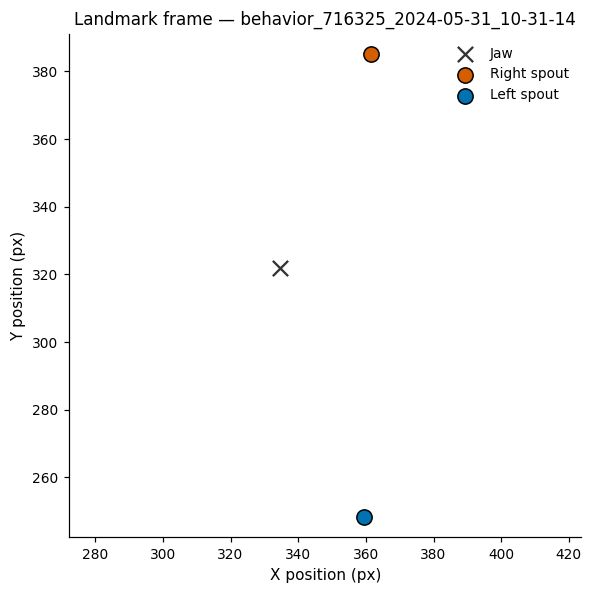

Jaw to right spout:  dx=  26.98  dy=  63.31  euclidean=  68.82
Jaw to left spout:   dx=  25.01  dy= -73.47  euclidean=  77.61
Between spouts:      dx=   1.97  dy= 136.78

behavior_716325_2024-05-31_10-31-14 jaw source: keypoint
jaw_positions: x=334.52 y=321.75   keypoint mean here: x=334.52 y=321.75


In [30]:
# Example session for the landmark figures — the session cueresponse itself used.
EXAMPLE_SESSION = "behavior_716325_2024-05-31_10-31-14"

if not IS_CO:
    print("[skip] Landmark frame: Code Ocean only (needs per-session kps_raw_*.parquet "
          "for absolute spout positions).")
else:
    kps_raw = load_kps_raw(SESSION_DIR / EXAMPLE_SESSION / "intermediate_data")

    jaw_coords    = kps_raw["jaw"][["x", "y"]].mean()
    spoutL_coords = kps_raw["spout_l"][["x", "y"]].mean()   # animal's right spout
    spoutR_coords = kps_raw["spout_r"][["x", "y"]].mean()   # animal's left spout

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    plot_standard_lick_landmarks(jaw_coords, spoutL_coords, spoutR_coords, ax=ax)
    ax.set(xlabel="X position (px)", ylabel="Y position (px)",
           title="Landmark frame — {}".format(EXAMPLE_SESSION))
    ax.axis("equal")
    ax.legend()
    style_ax(ax)
    plt.tight_layout()
    save_fig(fig, "landmark_frame", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    # Jaw <-> spout scale (cueresponse cell 94): establishes the pixel scale that makes
    # every excursion magnitude below interpretable.
    r_x, r_y = spoutL_coords["x"], spoutL_coords["y"]
    l_x, l_y = spoutR_coords["x"], spoutR_coords["y"]
    jaw_x, jaw_y = jaw_coords["x"], jaw_coords["y"]

    print("Jaw to right spout:  dx={:7.2f}  dy={:7.2f}  euclidean={:7.2f}".format(
        r_x - jaw_x, r_y - jaw_y, np.hypot(r_x - jaw_x, r_y - jaw_y)))
    print("Jaw to left spout:   dx={:7.2f}  dy={:7.2f}  euclidean={:7.2f}".format(
        l_x - jaw_x, l_y - jaw_y, np.hypot(l_x - jaw_x, l_y - jaw_y)))
    print("Between spouts:      dx={:7.2f}  dy={:7.2f}".format(r_x - l_x, r_y - l_y))

    # §2.1's get_jaw_positions already used this same keypoint file for EXAMPLE_SESSION
    # (it tries every session's kps_raw_jaw.parquet before falling back), so jaw_positions
    # here should already equal (jaw_x, jaw_y) exactly rather than needing a fresh check.
    est = jaw_positions.loc[EXAMPLE_SESSION]
    print("\n{} jaw source: {}".format(EXAMPLE_SESSION, est["jaw_source"]))
    print("jaw_positions: x={:.2f} y={:.2f}   keypoint mean here: x={:.2f} y={:.2f}".format(
        est["jaw_x"], est["jaw_y"], jaw_x, jaw_y))

## 4. Cue-response endpoints by lick side (Code Ocean only)

The cue-response movement's point of maximum excursion (`max_x_from_jaw`,
`max_x_from_jaw_y`), coloured by which lickometer the contact registered on, drawn over
the landmarks — `cueresponse` cell 93. This is the figure that shows the two spouts are
separable in raw endpoint space at all, which is the premise for §7-§8.

One session only, because the landmarks are per-session. The pooled version of the same
claim is the `endpoint_y_rel` split printed at the end of §2, and §7's binned curves.

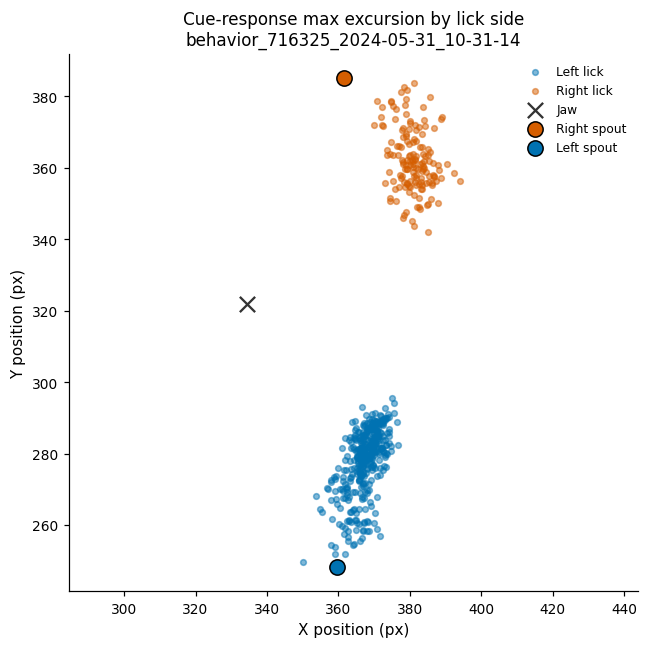

In [31]:
if not IS_CO:
    print("[skip] Endpoints over landmarks: Code Ocean only (needs per-session spout keypoints).")
else:
    sess_cue = df[(df["session"] == EXAMPLE_SESSION) & df["cue_response"]]

    fig, ax = plt.subplots(figsize=(6, 6))
    for side in ["left_lick_time", "right_lick_time"]:
        sub = sess_cue[sess_cue["event"] == side]
        ax.scatter(sub["max_x_from_jaw"], sub["max_x_from_jaw_y"],
                   s=14, alpha=0.5, color=SIDE_COLOR[side], label=SIDE_LABEL[side])
    other = sess_cue[~sess_cue["event"].isin(SIDE_COLOR)]
    if len(other):
        ax.scatter(other["max_x_from_jaw"], other["max_x_from_jaw_y"],
                   s=14, alpha=0.4, color=PALETTE["not_sig"], label="Other/none")

    plot_standard_lick_landmarks(jaw_coords, spoutL_coords, spoutR_coords, ax=ax)
    ax.set(xlabel="X position (px)", ylabel="Y position (px)",
           title="Cue-response max excursion by lick side\n{}".format(EXAMPLE_SESSION))
    ax.axis("equal")
    ax.legend(fontsize=8)
    style_ax(ax)
    plt.tight_layout()
    save_fig(fig, "cue_response_endpoints_by_side", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

## 5. Lick vs. non-lick excursion geometry (pooled)

Where does the tongue actually go when a movement registers no lick? This is the
max-excursion scatter that `tongue_kinematics` cell 60 and `cueresponse` cell 95 both
draw — the **same** figure in two HOLD notebooks; ported once, here.

Two departures from the source:

1. **Pooled, not single-session.** 44 sessions instead of one, in the jaw-centered frame
   from §2.1. The source overlaid absolute spout landmarks on this scatter; those are
   per-session and cannot follow the data into the pooled frame, so they are dropped
   here and the jaw origin marks the frame instead. (The landmark version of the same
   picture is §3-§4.)
2. **2-D density rather than raw points.** At 246k movements an alpha scatter saturates;
   the source's ~7k-point version did not have that problem.

Lick-associated movements: 151,404   non-lick movements: 94,955


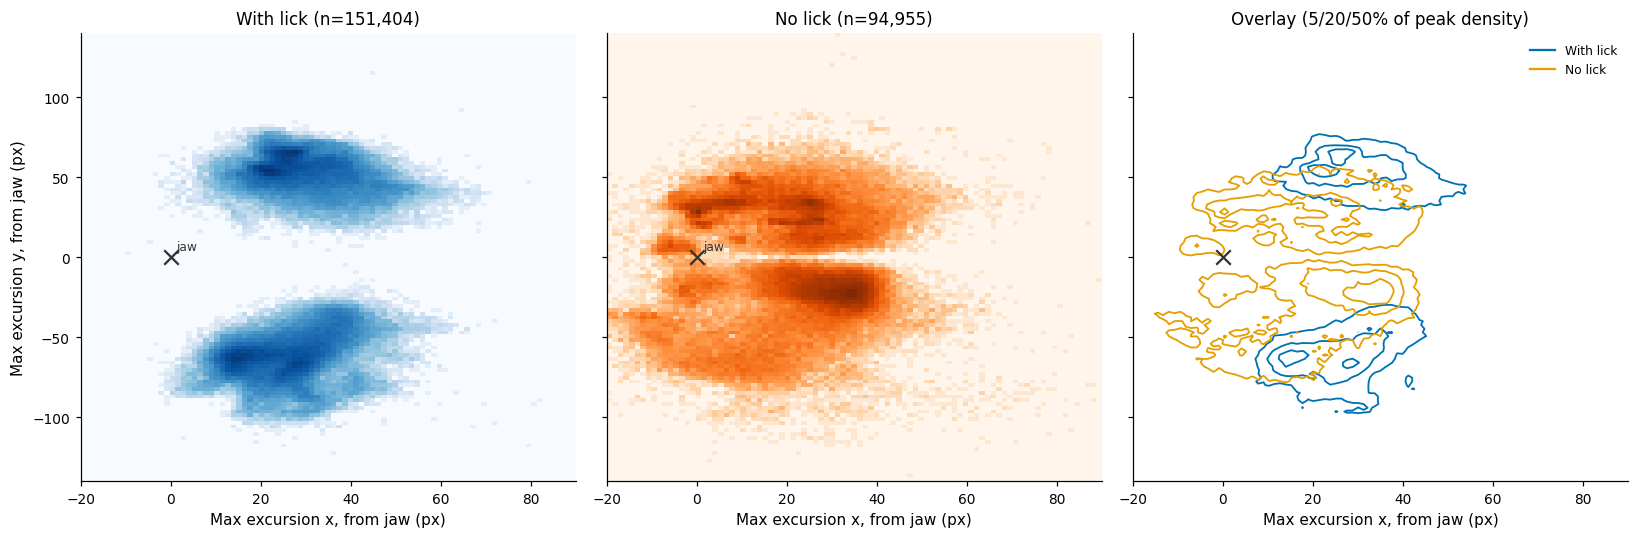


Max excursion distance from jaw (px), mean +/- SD:
  with lick   65.35 +/- 10.92
  no lick     40.78 +/- 15.74


In [32]:
lick_movs = df[df["has_lick"] == True]
nonlick_movs = df[df["has_lick"] == False]
print("Lick-associated movements: {:,}   non-lick movements: {:,}".format(
    len(lick_movs), len(nonlick_movs)))

XLIM, YLIM = (-20, 90), (-140, 140)
bins = [np.linspace(XLIM[0], XLIM[1], 90), np.linspace(YLIM[0], YLIM[1], 120)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
panels = [("With lick", lick_movs, "Blues"), ("No lick", nonlick_movs, "Oranges")]
for ax, (title, sub, cmap) in zip(axes[:2], panels):
    h, xe, ye = np.histogram2d(sub["max_x_from_jaw_rel"], sub["max_y_from_jaw_rel"], bins=bins)
    ax.pcolormesh(xe, ye, np.log10(h.T + 1), cmap=cmap, shading="auto")
    ax.scatter(0, 0, marker="x", s=90, c=PALETTE["all"], zorder=5)
    ax.annotate("jaw", (0, 0), xytext=(4, 5), textcoords="offset points",
                fontsize=8, color=PALETTE["all"])
    ax.set(title="{} (n={:,})".format(title, len(sub)), xlabel="Max excursion x, from jaw (px)")
    style_ax(ax)
axes[0].set_ylabel("Max excursion y, from jaw (px)")

# Third panel: the overlay the source drew, as contours so both populations stay visible.
for title, sub, color in [("With lick", lick_movs, SIDE_COLOR["left_lick_time"]),
                          ("No lick", nonlick_movs, PALETTE["sig"])]:
    h, xe, ye = np.histogram2d(sub["max_x_from_jaw_rel"], sub["max_y_from_jaw_rel"], bins=bins)
    hn = h.T / h.max()
    xc, yc = (xe[:-1] + xe[1:]) / 2, (ye[:-1] + ye[1:]) / 2
    axes[2].contour(xc, yc, hn, levels=[0.05, 0.2, 0.5], colors=color, linewidths=1.2)
axes[2].scatter(0, 0, marker="x", s=90, c=PALETTE["all"], zorder=5)
axes[2].set(title="Overlay (5/20/50% of peak density)", xlabel="Max excursion x, from jaw (px)")
axes[2].legend(handles=[Line2D([0], [0], color=SIDE_COLOR["left_lick_time"], label="With lick"),
                        Line2D([0], [0], color=PALETTE["sig"], label="No lick")], fontsize=8)
style_ax(axes[2])
axes[0].set(xlim=XLIM, ylim=YLIM)

plt.tight_layout()
save_fig(fig, "max_excursion_lick_vs_nonlick", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("\nMax excursion distance from jaw (px), mean +/- SD:")
for label, sub in [("with lick", lick_movs), ("no lick", nonlick_movs)]:
    d = np.hypot(sub["max_x_from_jaw_rel"], sub["max_y_from_jaw_rel"])
    print("  {:<10s} {:6.2f} +/- {:5.2f}".format(label, d.mean(), d.std()))

Per-session median excursion (n=44 sessions):
  with lick: 66.17 px    no lick: 39.43 px
  Wilcoxon signed-rank p = 1.14e-13


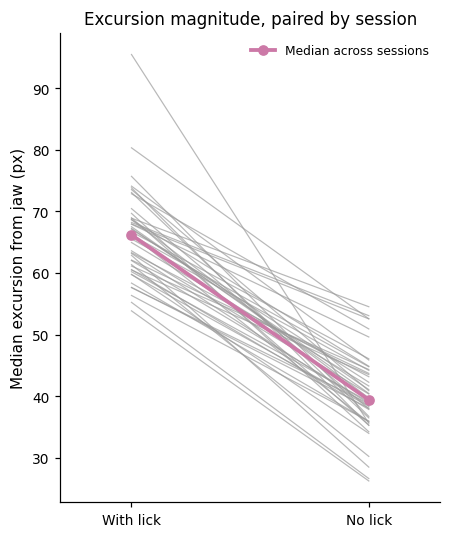

In [33]:
# Session as the sampling unit: does the lick / non-lick excursion difference hold within
# session, or is it carried by a few sessions? Paired across the 44 sessions.
per_session_excursion = (
    df.assign(excursion=np.hypot(df["max_x_from_jaw_rel"], df["max_y_from_jaw_rel"]))
      .groupby(["session", "has_lick"])["excursion"].median().unstack()
      .rename(columns={True: "with_lick", False: "no_lick"}).dropna()
)
w = stats.wilcoxon(per_session_excursion["with_lick"], per_session_excursion["no_lick"])
print("Per-session median excursion (n={} sessions):".format(len(per_session_excursion)))
print("  with lick: {:.2f} px    no lick: {:.2f} px".format(
    per_session_excursion["with_lick"].median(), per_session_excursion["no_lick"].median()))
print("  Wilcoxon signed-rank p {}".format(fmt_p(w.pvalue)))

fig, ax = plt.subplots(figsize=(4.2, 5))
for _, row in per_session_excursion.iterrows():
    ax.plot([0, 1], [row["with_lick"], row["no_lick"]], color=PALETTE["not_sig"], lw=0.8, alpha=0.7)
ax.plot([0, 1], per_session_excursion[["with_lick", "no_lick"]].median(),
        color=PALETTE["accent"], lw=2.5, marker="o", label="Median across sessions")
ax.set(xticks=[0, 1], xticklabels=["With lick", "No lick"],
       ylabel="Median excursion from jaw (px)", xlim=(-0.3, 1.3),
       title="Excursion magnitude, paired by session")
ax.legend(fontsize=8)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "excursion_paired_by_session", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Non-lick endpoints by movement ordinal

`cueresponse` cells 54 and 56: where non-lick movement endpoints sit, and whether that
changes with the movement's ordinal position in the trial. If early non-lick movements
are short, midline "probes" and later ones drift toward a spout, the ordinal should show
a spatial gradient.

The source referenced two names (`nonlick`, `licks`) that it never defined — leftovers
from another notebook. They are reconstructed here as the obvious `has_lick` split.

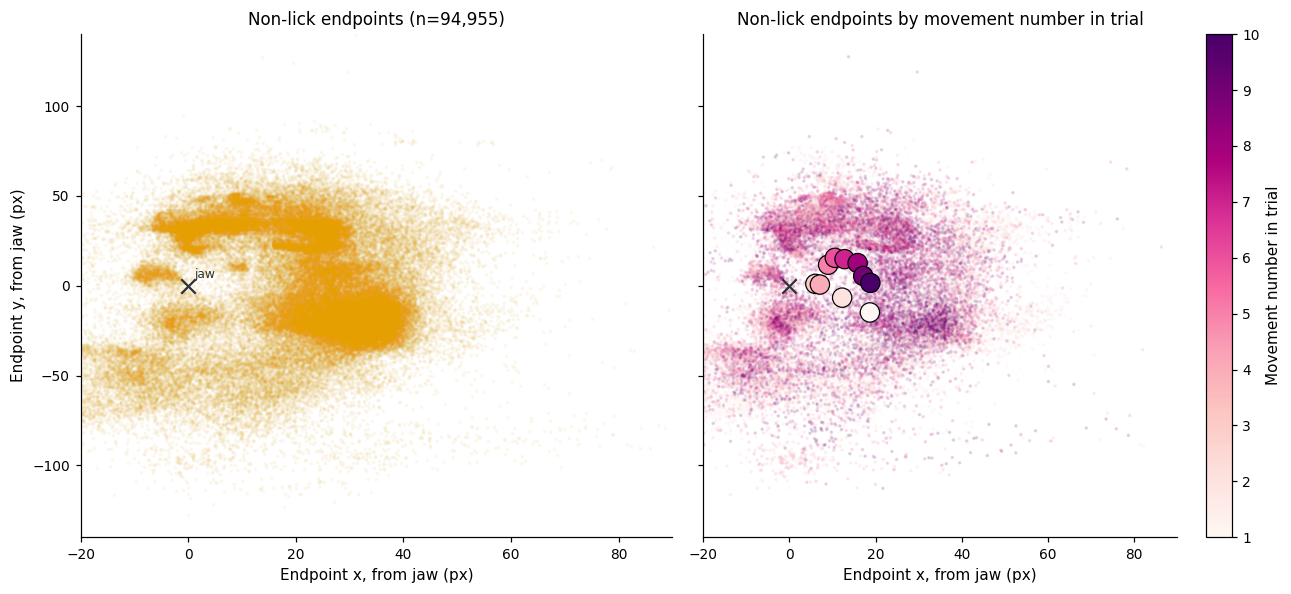

Median non-lick endpoint by ordinal (jaw-centered px):
                          endpoint_x_rel  endpoint_y_rel     n
movement_number_in_trial                                      
1                                  18.69          -14.90  7600
2                                  12.25           -6.66  3233
3                                   6.02            1.02  2974
4                                   7.08            0.64  3085
5                                   8.98           11.66  2780
6                                  10.54           15.51  2714
7                                  12.81           14.78  2488
8                                  15.85           12.60  2413
9                                  17.15            5.41  2400
10                                 18.80            1.56  2387


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

# Left: non-lick endpoints alone.
axes[0].scatter(nonlick_movs["endpoint_x_rel"], nonlick_movs["endpoint_y_rel"],
                s=2, alpha=0.05, color=PALETTE["sig"], rasterized=True)
axes[0].scatter(0, 0, marker="x", s=90, c=PALETTE["all"], zorder=5)
axes[0].annotate("jaw", (0, 0), xytext=(4, 5), textcoords="offset points",
                 fontsize=8, color=PALETTE["all"])
axes[0].set(title="Non-lick endpoints (n={:,})".format(len(nonlick_movs)),
            xlabel="Endpoint x, from jaw (px)", ylabel="Endpoint y, from jaw (px)")
style_ax(axes[0])

# Right: coloured by ordinal position within trial, binned to a median per ordinal so the
# gradient is legible rather than buried under 250k overplotted points.
ordinals = np.arange(1, 11)
sub = nonlick_movs[nonlick_movs["movement_number_in_trial"].isin(ordinals)]
axes[1].scatter(sub["endpoint_x_rel"], sub["endpoint_y_rel"],
                c=sub["movement_number_in_trial"].astype(float), cmap="RdPu",
                vmin=1, vmax=10, s=2, alpha=0.12, rasterized=True)
by_ord = sub.groupby("movement_number_in_trial")[["endpoint_x_rel", "endpoint_y_rel"]].median()
sc = axes[1].scatter(by_ord["endpoint_x_rel"], by_ord["endpoint_y_rel"],
                     c=by_ord.index.astype(float), cmap="RdPu", vmin=1, vmax=10,
                     s=160, edgecolors="k", linewidths=0.8, zorder=6)
axes[1].scatter(0, 0, marker="x", s=90, c=PALETTE["all"], zorder=7)
axes[1].set(title="Non-lick endpoints by movement number in trial",
            xlabel="Endpoint x, from jaw (px)")
plt.colorbar(sc, ax=axes[1], label="Movement number in trial")
style_ax(axes[1])
axes[0].set(xlim=(-20, 90), ylim=(-140, 140))

plt.tight_layout()
save_fig(fig, "nonlick_endpoints_by_ordinal", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Median non-lick endpoint by ordinal (jaw-centered px):")
print(by_ord.join(sub.groupby("movement_number_in_trial").size().rename("n")).to_string(
    float_format=lambda v: "{:.2f}".format(v)))

## 7. Does pre-lick direction predict choice?

The question the notebook exists for. For each trial with a cue response, take the
**last** movement that precedes the cue-response lick (`movement_before_cue_response`)
and ask whether its geometry anticipates which spout the animal then licks.

`cueresponse` cells 49 and 55, pooled. Three changes from the source:

- `trial` repeats across sessions in the pooled parquet, so every grouping here is on
  `(session, trial)`. The source, single-session, grouped on `trial` alone.
- The binned P(right lick) curves bin within session and then average **across sessions**
  (mean ± SEM over sessions), so the sampling unit is the session — the convention the
  rest of the `kin_` series uses — rather than the movement.
- `endpoint_y` is jaw-centered (§2.1); the source's raw pixel axis is not comparable
  across sessions.

In [35]:
# One row per (session, trial): the last pre-cue-response movement, labelled by the side
# the animal subsequently licked.
valid_trials = df.loc[df["cue_response"], ["session", "trial"]].drop_duplicates()
df_valid = df.merge(valid_trials, on=["session", "trial"], how="inner")

prelick = df_valid[df_valid["movement_before_cue_response"] == True].copy()
last_prelick = (
    prelick.sort_values(["session", "trial", "movement_number_in_trial"])
           .groupby(["session", "trial"]).last().reset_index()
)

cue_labels = (
    df_valid[df_valid["cue_response"]]
    .drop_duplicates(["session", "trial"])[["session", "trial", "event"]]
)
last_prelick = last_prelick.drop(columns=["event"]).merge(
    cue_labels.rename(columns={"event": "cue_lick_direction"}),
    on=["session", "trial"], how="left")
last_prelick = last_prelick[last_prelick["cue_lick_direction"].isin(SIDE_COLOR)].copy()
last_prelick["is_right"] = (last_prelick["cue_lick_direction"] == "right_lick_time").astype(float)

n_sess = last_prelick["session"].nunique()
balance = last_prelick["cue_lick_direction"].value_counts()
print("Trials with a pre-cue-response movement and a labelled cue-response lick: "
      "{:,} across {} sessions".format(len(last_prelick), n_sess))
print("\nClass balance (this is the baseline any AUC/accuracy below must beat):")
for side, n in balance.items():
    print("  {:<16s} {:5,d}  ({:.1%})".format(side, n, n / len(last_prelick)))
print("  majority-class accuracy: {:.3f}   chance AUC: 0.500".format(balance.max() / len(last_prelick)))
print("\nTrials per session: median {:.0f}, range {:.0f}-{:.0f}".format(
    last_prelick.groupby("session").size().median(),
    last_prelick.groupby("session").size().min(),
    last_prelick.groupby("session").size().max()))

Trials with a pre-cue-response movement and a labelled cue-response lick: 7,138 across 44 sessions

Class balance (this is the baseline any AUC/accuracy below must beat):
  left_lick_time   4,135  (57.9%)
  right_lick_time  3,003  (42.1%)
  majority-class accuracy: 0.579   chance AUC: 0.500

Trials per session: median 148, range 9-405


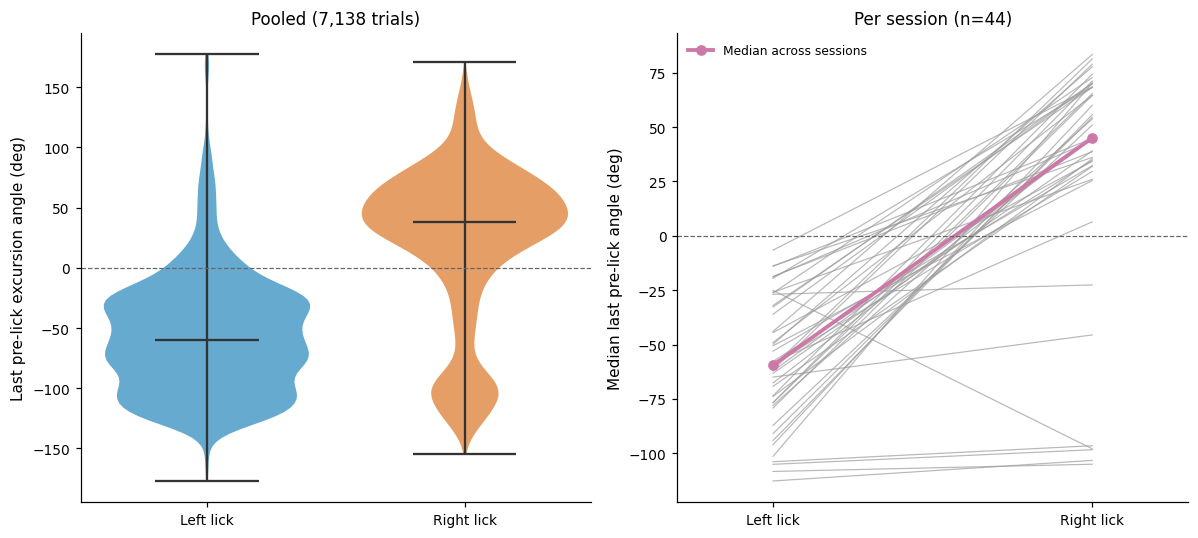

left_lick_time   n=4,135  median  -59.96 deg  IQR  -94.54 ..  -26.22
right_lick_time  n=3,003  median   38.46 deg  IQR   -0.16 ..   63.75
Mann-Whitney U (movements): p < 1e-300
Wilcoxon signed-rank (sessions, n=44): p = 1e-11


In [36]:
# Last pre-lick excursion angle by the side subsequently licked (cueresponse cell 49).
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sides = ["left_lick_time", "right_lick_time"]
data = [last_prelick.loc[last_prelick["cue_lick_direction"] == s, "excursion_angle_deg"].dropna()
        for s in sides]
parts = axes[0].violinplot(data, positions=[0, 1], showmedians=True, widths=0.8)
for body, s in zip(parts["bodies"], sides):
    body.set_facecolor(SIDE_COLOR[s])
    body.set_alpha(0.6)
for key in ("cbars", "cmins", "cmaxes", "cmedians"):
    parts[key].set_color(PALETTE["all"])
axes[0].axhline(0, color=PALETTE["neutral"], ls="--", lw=0.8)
axes[0].set(xticks=[0, 1], xticklabels=[SIDE_LABEL[s] for s in sides],
            ylabel="Last pre-lick excursion angle (deg)",
            title="Pooled ({:,} trials)".format(len(last_prelick)))
style_ax(axes[0])

# Session as the sampling unit: per-session medians, paired.
paired = (last_prelick.groupby(["session", "cue_lick_direction"])["excursion_angle_deg"]
          .median().unstack().dropna())
for _, row in paired.iterrows():
    axes[1].plot([0, 1], [row["left_lick_time"], row["right_lick_time"]],
                 color=PALETTE["not_sig"], lw=0.8, alpha=0.7)
axes[1].plot([0, 1], [paired["left_lick_time"].median(), paired["right_lick_time"].median()],
             color=PALETTE["accent"], lw=2.5, marker="o", label="Median across sessions")
axes[1].axhline(0, color=PALETTE["neutral"], ls="--", lw=0.8)
axes[1].set(xticks=[0, 1], xticklabels=[SIDE_LABEL[s] for s in sides], xlim=(-0.3, 1.3),
            ylabel="Median last pre-lick angle (deg)",
            title="Per session (n={})".format(len(paired)))
axes[1].legend(fontsize=8)
style_ax(axes[1])

plt.tight_layout()
save_fig(fig, "prelick_angle_by_lick_side", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

for s in sides:
    g = last_prelick.loc[last_prelick["cue_lick_direction"] == s, "excursion_angle_deg"]
    print("{:<16s} n={:5,d}  median {:7.2f} deg  IQR {:7.2f} .. {:7.2f}".format(
        s, len(g), g.median(), g.quantile(0.25), g.quantile(0.75)))
print("Mann-Whitney U (movements): p {}".format(
    fmt_p(stats.mannwhitneyu(data[1], data[0]).pvalue)))
print("Wilcoxon signed-rank (sessions, n={}): p {}".format(
    len(paired), fmt_p(stats.wilcoxon(paired["right_lick_time"], paired["left_lick_time"]).pvalue)))


P(right lick) vs endpoint_y_rel (mean +/- SEM over sessions):
        x  p_mean  p_sem  n_sessions
0 -70.551   0.081  0.040          20
1 -54.991   0.119  0.045          26
2 -41.013   0.156  0.051          32
3 -30.099   0.104  0.032          34
4 -18.503   0.130  0.042          32
5  -2.167   0.375  0.057          35
6  16.449   0.758  0.040          36
7  28.844   0.911  0.019          37
8  40.255   0.935  0.021          29

P(right lick) vs excursion_angle_deg (mean +/- SEM over sessions):
         x  p_mean  p_sem  n_sessions
0 -119.579   0.090  0.042          16
1  -99.139   0.115  0.046          23
2  -77.214   0.139  0.055          31
3  -52.653   0.095  0.032          36
4  -30.513   0.145  0.045          29
5   -2.810   0.431  0.064          30
6   29.129   0.820  0.037          31
7   52.517   0.880  0.026          32
8   88.648   0.881  0.035          28


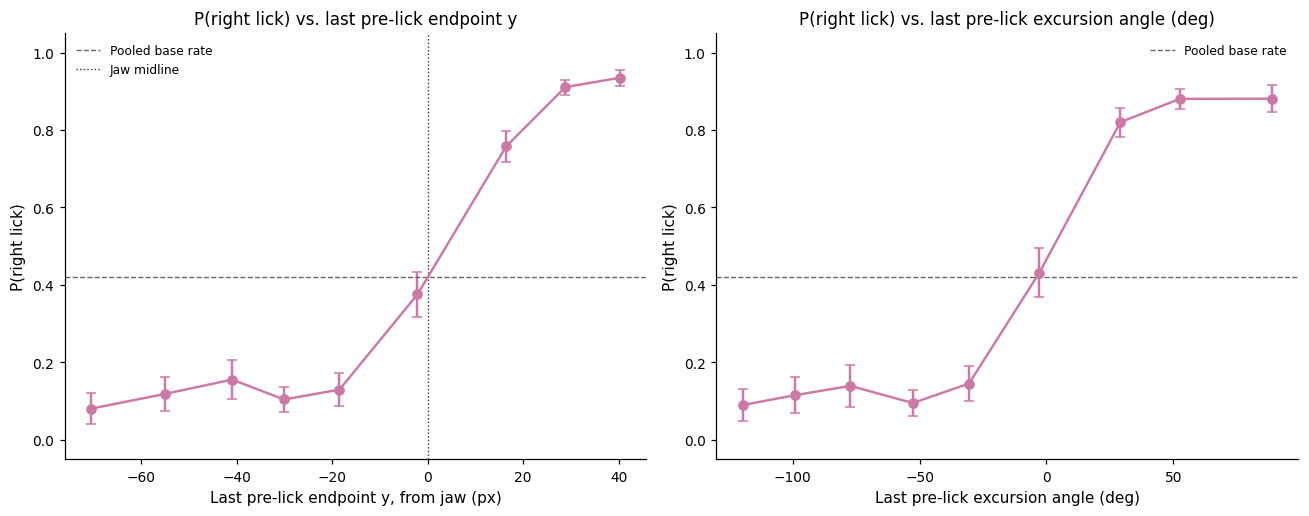

In [37]:
def binned_p_right_by_session(trials, x_col, n_bins=9, min_per_bin=5):
    """Bin P(right lick) against a pre-lick kinematic variable, session-wise.

    Bin edges are pooled quantiles (so bins are comparable across sessions), but
    the proportion is computed **within** each session and then averaged across
    sessions. The sampling unit is therefore the session, not the trial — the
    convention used elsewhere in the ``kin_`` series for population claims.

    Parameters
    ----------
    trials : pandas.DataFrame
        One row per (session, trial), with ``session``, ``is_right`` (0/1) and
        ``x_col``.
    x_col : str
        Column to bin on.
    n_bins : int
        Number of quantile bins.
    min_per_bin : int
        Minimum trials for a session to contribute to a bin.

    Returns
    -------
    pandas.DataFrame
        One row per bin: ``x`` (mean x), ``p_mean``, ``p_sem``, ``n_sessions``.
    """
    edges = np.nanquantile(trials[x_col], np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-9
    edges[-1] += 1e-9

    binned = trials.dropna(subset=[x_col]).copy()
    # Integer bin labels rather than a pandas Interval categorical: the group keys stay
    # plain ints, which keeps the two groupbys below off pandas' object-hashing path.
    binned["x_bin"] = pd.cut(binned[x_col], edges, labels=False)

    per_session = (binned.groupby(["session", "x_bin"])
                   .agg(p=("is_right", "mean"), x=(x_col, "mean"), n=("is_right", "size"))
                   .reset_index())
    per_session = per_session[per_session["n"] >= min_per_bin]

    out = (per_session.groupby("x_bin")
           .agg(x=("x", "mean"), p_mean=("p", "mean"),
                p_sem=("p", lambda s: s.std(ddof=1) / np.sqrt(len(s))),
                n_sessions=("p", "size")))
    return out.dropna().reset_index(drop=True)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
specs = [("endpoint_y_rel", "Last pre-lick endpoint y, from jaw (px)"),
         ("excursion_angle_deg", "Last pre-lick excursion angle (deg)")]

for ax, (col, xlabel) in zip(axes, specs):
    b = binned_p_right_by_session(last_prelick, col)
    ax.errorbar(b["x"], b["p_mean"], yerr=b["p_sem"], fmt="o-", capsize=3,
                color=PALETTE["accent"], lw=1.6)
    ax.axhline(last_prelick["is_right"].mean(), color=PALETTE["neutral"], ls="--", lw=0.9,
               label="Pooled base rate")
    if col == "endpoint_y_rel":
        ax.axvline(0, color=PALETTE["all"], ls=":", lw=0.9, label="Jaw midline")
    ax.set(xlabel=xlabel, ylabel="P(right lick)", ylim=(-0.05, 1.05),
           title="P(right lick) vs. " + xlabel.split(",")[0].lower())
    ax.legend(fontsize=8)
    style_ax(ax)
    print("\nP(right lick) vs {} (mean +/- SEM over sessions):".format(col))
    print(b.to_string(float_format=lambda v: "{:.3f}".format(v)))

plt.tight_layout()
save_fig(fig, "p_right_lick_binned", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 8. Ridge-logistic decode of lick side

`cueresponse` cells 44, 47 and 48: standardized ridge-logistic regression predicting
left vs. right cue-response lick from summary statistics of the trial's pre-lick
movements.

**Why the source's evaluation cannot be reused as-is.** It calls
`train_test_split(random_state=42)` on trials from a single session. Applied to pooled
data that split puts trials from the same session on both sides, so the model can learn
session-specific camera geometry and score itself on it. Two evaluations are used here
instead, answering different questions:

- **`GroupKFold` with session as the group (primary).** Every test session is entirely
  unseen during training. This asks whether *one* geometry→choice mapping generalizes
  across animals and rigs — the population claim.
- **Per-session fits (secondary).** A separate model per session, stratified 70/30 splits
  within it, reported as a distribution of AUCs across sessions. This asks whether the
  mapping exists *within* a session even if its parameters differ between them, which is
  the honest fallback if the shared decoder fails on camera-frame differences.

Plus a **shuffled-label null**: labels permuted *within* session (preserving each
session's own left/right base rate) and the whole `GroupKFold` procedure re-run.

In [38]:
FEATURES = ["mean_angle", "last_angle", "mean_duration", "mean_distance",
            "mean_peak_v", "max_peak_v", "total_prelicks", "session_time"]

features = (
    prelick.groupby(["session", "trial"]).agg(
        mean_angle=("excursion_angle_deg", "mean"),
        last_angle=("excursion_angle_deg", "last"),
        mean_duration=("duration", "mean"),
        mean_distance=("total_distance", "mean"),
        mean_peak_v=("peak_velocity", "mean"),
        max_peak_v=("peak_velocity", "max"),
        total_prelicks=("movement_id", "count"),
        session_time=("goCue_start_time_in_session", "mean"),
    )
)
features = (features.reset_index()
            .merge(cue_labels, on=["session", "trial"], how="left")
            .set_index(["session", "trial"]))
features = features[features["event"].isin(SIDE_COLOR)].dropna()

X = features[FEATURES]
y = (features["event"] == "right_lick_time").astype(int)
groups = features.index.get_level_values("session")

print("Decode table: {:,} trials x {} features, {} sessions".format(
    len(features), len(FEATURES), groups.nunique()))
print("Positive class (right lick): {:.1%}".format(y.mean()))


def make_decoder():
    """Build the standardized ridge-logistic pipeline used throughout §8.

    Returns
    -------
    sklearn.pipeline.Pipeline
        StandardScaler followed by L2-penalized logistic regression (C=1.0),
        matching the source notebook's specification.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(penalty="l2", C=1.0, max_iter=1000)),
    ])

Decode table: 7,077 trials x 8 features, 44 sessions
Positive class (right lick): 42.0%


In [39]:
# Primary: GroupKFold with session as the group.
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

fold_aucs = []
oof_pred = np.full(len(y), np.nan)
for train_idx, test_idx in gkf.split(X, y, groups):
    model = make_decoder().fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict_proba(X.iloc[test_idx])[:, 1]
    oof_pred[test_idx] = pred
    fold_aucs.append(roc_auc_score(y.iloc[test_idx], pred))

fold_aucs = np.array(fold_aucs)
print("GroupKFold (session) fold AUCs:", np.round(fold_aucs, 3))
print("Mean AUC across held-out session folds: {:.3f} +/- {:.3f} (SD)".format(
    fold_aucs.mean(), fold_aucs.std()))
print("Pooled out-of-fold AUC: {:.3f}".format(roc_auc_score(y, oof_pred)))
print("\nOut-of-fold classification report (threshold 0.5):")
print(classification_report(y, (oof_pred > 0.5).astype(int),
                            target_names=["left", "right"], digits=3))

GroupKFold (session) fold AUCs: [0.788 0.89  0.668 0.963 0.864]
Mean AUC across held-out session folds: 0.835 +/- 0.100 (SD)
Pooled out-of-fold AUC: 0.836

Out-of-fold classification report (threshold 0.5):
              precision    recall  f1-score   support

        left      0.810     0.873     0.841      4103
       right      0.804     0.718     0.759      2974

    accuracy                          0.808      7077
   macro avg      0.807     0.796     0.800      7077
weighted avg      0.808     0.808     0.806      7077



In [40]:
# Shuffled-label null: permute the label within session, preserving each session's own
# left/right base rate, and re-run the full GroupKFold procedure.
N_PERM = 200
rng = np.random.default_rng(0)
null_aucs = []
for _ in range(N_PERM):
    y_perm = y.values.copy()
    for s in np.unique(groups):
        mask = groups == s
        y_perm[mask] = rng.permutation(y_perm[mask])
    y_perm = pd.Series(y_perm, index=y.index)
    a = []
    for train_idx, test_idx in gkf.split(X, y_perm, groups):
        model = make_decoder().fit(X.iloc[train_idx], y_perm.iloc[train_idx])
        a.append(roc_auc_score(y_perm.iloc[test_idx], model.predict_proba(X.iloc[test_idx])[:, 1]))
    null_aucs.append(np.mean(a))

null_aucs = np.array(null_aucs)
p_perm = (np.sum(null_aucs >= fold_aucs.mean()) + 1) / (N_PERM + 1)
print("Null (labels shuffled within session, {} permutations):".format(N_PERM))
print("  mean {:.3f}, 95th pct {:.3f}, max {:.3f}".format(
    null_aucs.mean(), np.percentile(null_aucs, 95), null_aucs.max()))
print("  observed {:.3f},  p = {:.3g}  (resolution floor {:.3g} at {} permutations)".format(
    fold_aucs.mean(), p_perm, 1 / (N_PERM + 1), N_PERM))
# The null sits slightly above 0.5 because within-session shuffling leaves session-level
# base rates intact, which a pooled evaluation can exploit; that offset is the correct
# reference for the observed value, not 0.5.

Null (labels shuffled within session, 200 permutations):
  mean 0.530, 95th pct 0.545, max 0.553
  observed 0.835,  p = 0.00498  (resolution floor 0.00498 at 200 permutations)


Per-session decode (39 of 44 sessions met n>=40 with >=10 per class):
  median AUC 0.943, mean 0.915, IQR 0.903-0.981, 97% above 0.5
  Wilcoxon signed-rank vs 0.5: p = 7.28e-12


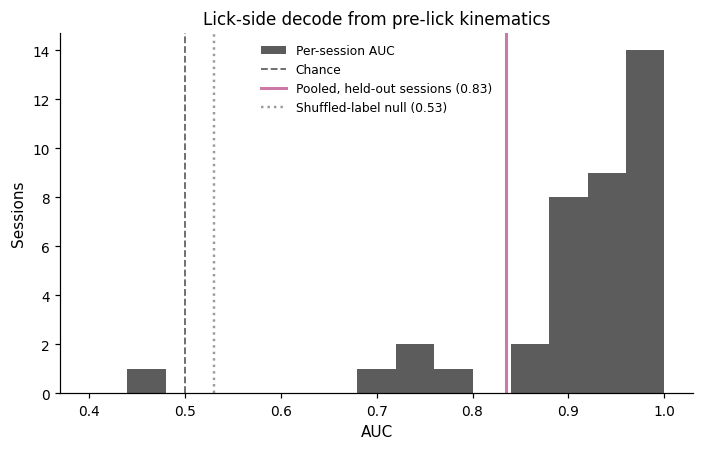

In [41]:
# Secondary: per-session fits, AUC distribution across sessions.
MIN_TRIALS, MIN_MINORITY = 40, 10
per_session_auc = []
for session, grp in features.groupby(level="session"):
    yy = (grp["event"] == "right_lick_time").astype(int)
    if len(grp) < MIN_TRIALS or min(yy.sum(), len(yy) - yy.sum()) < MIN_MINORITY:
        continue
    splitter = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=42)
    aucs = [roc_auc_score(yy.iloc[te],
                          make_decoder().fit(grp[FEATURES].iloc[tr], yy.iloc[tr])
                          .predict_proba(grp[FEATURES].iloc[te])[:, 1])
            for tr, te in splitter.split(grp[FEATURES], yy)]
    per_session_auc.append((session, len(grp), float(np.mean(aucs))))

per_session_auc = pd.DataFrame(per_session_auc, columns=["session", "n_trials", "auc"])
print("Per-session decode ({} of {} sessions met n>={} with >={} per class):".format(
    len(per_session_auc), groups.nunique(), MIN_TRIALS, MIN_MINORITY))
print("  median AUC {:.3f}, mean {:.3f}, IQR {:.3f}-{:.3f}, {:.0%} above 0.5".format(
    per_session_auc["auc"].median(), per_session_auc["auc"].mean(),
    per_session_auc["auc"].quantile(0.25), per_session_auc["auc"].quantile(0.75),
    (per_session_auc["auc"] > 0.5).mean()))
print("  Wilcoxon signed-rank vs 0.5: p {}".format(
    fmt_p(stats.wilcoxon(per_session_auc["auc"] - 0.5).pvalue)))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.hist(per_session_auc["auc"], bins=np.arange(0.4, 1.02, 0.04),
        color=PALETTE["all"], alpha=0.8, label="Per-session AUC")
ax.axvline(0.5, color=PALETTE["neutral"], ls="--", lw=1.2, label="Chance")
ax.axvline(fold_aucs.mean(), color=PALETTE["accent"], lw=2,
           label="Pooled, held-out sessions ({:.2f})".format(fold_aucs.mean()))
ax.axvline(null_aucs.mean(), color=PALETTE["not_sig"], ls=":", lw=1.6,
           label="Shuffled-label null ({:.2f})".format(null_aucs.mean()))
ax.set(xlabel="AUC", ylabel="Sessions", title="Lick-side decode from pre-lick kinematics")
ax.legend(fontsize=8)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "decode_auc_distribution", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

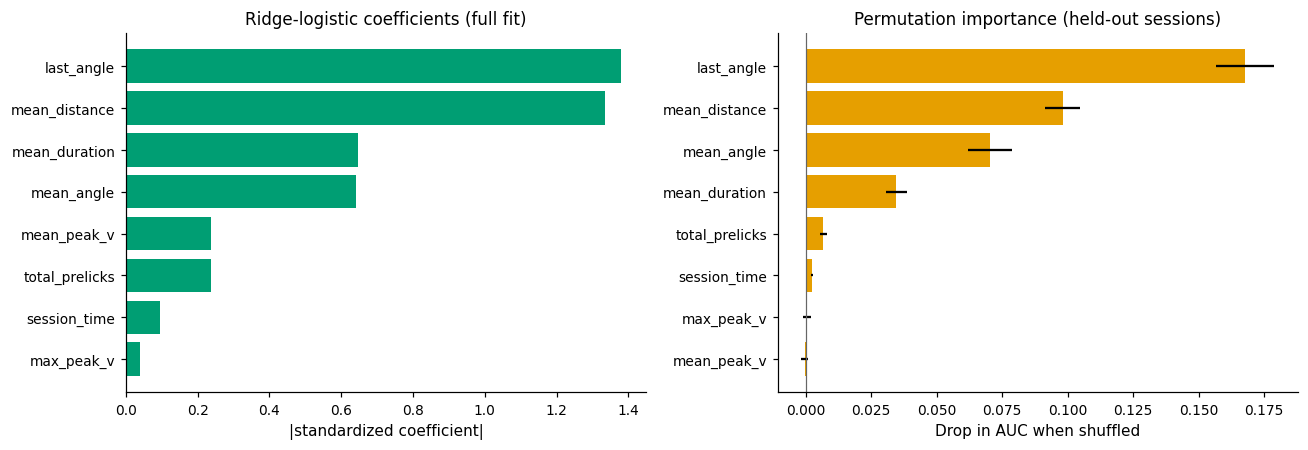

Permutation importance (mean dAUC):
last_angle        0.1677
mean_distance     0.0981
mean_angle        0.0704
mean_duration     0.0346
total_prelicks    0.0068
session_time      0.0026
max_peak_v        0.0007
mean_peak_v      -0.0003


In [42]:
# What carries the decode: absolute standardized coefficients (full fit) and permutation
# importance in AUC, measured on held-out *sessions* rather than held-out trials.
full_fit = make_decoder().fit(X, y)
coefs = pd.Series(np.abs(full_fit.named_steps["logreg"].coef_[0]), index=FEATURES).sort_values()

train_idx, test_idx = next(iter(gkf.split(X, y, groups)))
fold_model = make_decoder().fit(X.iloc[train_idx], y.iloc[train_idx])
perm = permutation_importance(fold_model, X.iloc[test_idx], y.iloc[test_idx],
                              n_repeats=30, random_state=42, scoring="roc_auc")
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
imp_sd = pd.Series(perm.importances_std, index=FEATURES).reindex(imp.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].barh(coefs.index, coefs.values, color=PALETTE["baseline"])
axes[0].set(xlabel="|standardized coefficient|", title="Ridge-logistic coefficients (full fit)")
style_ax(axes[0])
axes[1].barh(imp.index, imp.values, xerr=imp_sd.values, color=PALETTE["sig"])
axes[1].axvline(0, color=PALETTE["neutral"], lw=0.8)
axes[1].set(xlabel="Drop in AUC when shuffled",
            title="Permutation importance (held-out sessions)")
style_ax(axes[1])
plt.tight_layout()
save_fig(fig, "decode_feature_importance", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Permutation importance (mean dAUC):")
print(imp.sort_values(ascending=False).to_string(float_format=lambda v: "{:.4f}".format(v)))

### 8.4 Caveat — block structure and recent choice

**Left/right choice in this task is driven by block structure**, so a decoder that
predicts lick side may be exploiting recent-choice or block base rates rather than
movement direction. Two things make that a live concern here: `session_time` is in the
feature set (a within-session clock correlates with block identity), and animals are
strongly perseverative, so *yesterday's* prediction is a good predictor of today's.

This section does not resolve the confound — resolving it needs a block-aware design, and
`kin_07` will bring the behavioral-model latents that make it tractable. It quantifies it:

1. How well does the **previous trial's choice alone** predict this trial's choice?
2. Does the kinematic decode survive **within** previous-choice strata, where the
   perseverative signal is held constant?

In [43]:
# Previous cue-response choice, within session, only where the trials are consecutive.
choices = (df.loc[df["cue_response"]]
           .drop_duplicates(["session", "trial"])[["session", "trial", "event"]])
choices = choices[choices["event"].isin(SIDE_COLOR)].sort_values(["session", "trial"])
choices["choice"] = (choices["event"] == "right_lick_time").astype(int)
choices["prev_choice"] = choices.groupby("session")["choice"].shift(1)
choices["prev_trial"] = choices.groupby("session")["trial"].shift(1)
choices.loc[choices["trial"] - choices["prev_trial"] != 1, "prev_choice"] = np.nan

conf = (features.reset_index()
        .merge(choices[["session", "trial", "choice", "prev_choice"]], on=["session", "trial"])
        .dropna(subset=["prev_choice"]))
print("Trials with a valid preceding choice: {:,}".format(len(conf)))
print("P(stay) = {:.3f}".format((conf["choice"] == conf["prev_choice"]).mean()))
print("Previous choice alone, AUC = {:.3f}".format(
    roc_auc_score(conf["choice"], conf["prev_choice"])))


def grouped_auc(frame, cols, label_col="choice", group_col="session", n_splits=5):
    """Mean AUC of the ridge-logistic decoder under GroupKFold on `group_col`.

    Parameters
    ----------
    frame : pandas.DataFrame
        Trial-level table holding the feature columns, the label and the group.
    cols : list of str
        Feature column names.
    label_col : str
        Binary label column.
    group_col : str
        Grouping column held out whole by each fold (here, session).
    n_splits : int
        Number of folds.

    Returns
    -------
    float
        Mean AUC across folds.
    """
    Xg, yg, gg = frame[cols], frame[label_col], frame[group_col]
    scores = []
    for tr, te in GroupKFold(n_splits=n_splits).split(Xg, yg, gg):
        m = make_decoder().fit(Xg.iloc[tr], yg.iloc[tr])
        scores.append(roc_auc_score(yg.iloc[te], m.predict_proba(Xg.iloc[te])[:, 1]))
    return float(np.mean(scores))


print("Kinematics only,          AUC = {:.3f}".format(grouped_auc(conf, FEATURES)))
print("Kinematics + prev choice, AUC = {:.3f}".format(grouped_auc(conf, FEATURES + ["prev_choice"])))
for pc in [0, 1]:
    stratum = conf[conf["prev_choice"] == pc]
    print("  within prev_choice={} (n={:,}, P(right)={:.2f}): kinematics AUC = {:.3f}".format(
        int(pc), len(stratum), stratum["choice"].mean(), grouped_auc(stratum, FEATURES)))

Trials with a valid preceding choice: 6,720
P(stay) = 0.910
Previous choice alone, AUC = 0.907
Kinematics only,          AUC = 0.837
Kinematics + prev choice, AUC = 0.954
  within prev_choice=0 (n=3,964, P(right)=0.08): kinematics AUC = 0.815
  within prev_choice=1 (n=2,756, P(right)=0.90): kinematics AUC = 0.772


### 8.5 Reading the decode

Pre-lick tongue direction predicts the upcoming lick side, and the effect is not an
artifact of pooling:

- **Across held-out sessions**, AUC 0.84 ± 0.10 (SD over 5 session-grouped folds); the
  within-session shuffled-label null sits at 0.53, so the folds are far outside it.
- **Within session**, median AUC 0.94 over the 39 sessions with enough trials — higher
  than the shared decoder, which is what a session-specific camera frame predicts and is
  why both evaluations are reported rather than one.
- **What carries it** is direction, not vigor: `last_angle` and `mean_angle` plus
  `mean_distance` hold essentially all of the permutation importance, while both peak
  velocity terms and `session_time` sit at ~0. The near-zero `session_time` importance is
  reassuring against the block-structure confound, though it does not rule it out.

The confound that does bite is perseveration. **Previous choice alone reaches AUC 0.907**
— better than kinematics — because P(stay) = 0.91. Kinematics still reads AUC 0.77-0.82
*within* each previous-choice stratum, so it is not simply re-encoding choice history, but
the two are not separated here. That separation needs block-aware regressors, which is
`kin_07`'s dependency, not this notebook's.

## 9. Pre-lick → cue-response endpoint displacement

If the pre-lick movement is genuinely preparatory, its endpoint should already sit on the
side the animal then licks, with the cue-response lick carrying the tongue *further* in
the same direction rather than reversing it. `cueresponse` cells 50-52 draw this per
trial as a line from the pre-lick endpoint to the cue-response endpoint against the jaw
midline; here the midline is `endpoint_y_rel == 0` by construction, and both the
per-trial figure (one session, for legibility) and the pooled summary are shown.

In [44]:
cue_endpoints = (df.loc[df["cue_response"]]
                 .drop_duplicates(["session", "trial"])
                 [["session", "trial", "event", "endpoint_x_rel", "endpoint_y_rel"]]
                 .rename(columns={"endpoint_x_rel": "cue_x_rel", "endpoint_y_rel": "cue_y_rel"}))

paired_endpoints = last_prelick[["session", "trial", "endpoint_y_rel", "cue_lick_direction"]].merge(
    cue_endpoints[["session", "trial", "cue_y_rel", "event"]], on=["session", "trial"])
paired_endpoints = paired_endpoints[paired_endpoints["event"].isin(SIDE_COLOR)]
paired_endpoints["same_side"] = (
    np.sign(paired_endpoints["endpoint_y_rel"]) == np.sign(paired_endpoints["cue_y_rel"]))

print("Paired trials: {:,} across {} sessions\n".format(
    len(paired_endpoints), paired_endpoints["session"].nunique()))
for side, grp in paired_endpoints.groupby("event"):
    extra = (grp["cue_y_rel"].abs() - grp["endpoint_y_rel"].abs())
    print("{:<16s} n={:5,d}  pre-lick y {:7.2f}  cue-response y {:7.2f}  "
          "further from midline by {:6.2f} px  same side {:.1%}".format(
              side, len(grp), grp["endpoint_y_rel"].mean(), grp["cue_y_rel"].mean(),
              extra.mean(), grp["same_side"].mean()))
    print("      Wilcoxon |cue| > |pre|: p {}".format(
        fmt_p(stats.wilcoxon(grp["cue_y_rel"].abs(), grp["endpoint_y_rel"].abs()).pvalue)))

session_same_side = paired_endpoints.groupby("session")["same_side"].mean()
print("\nSession as sampling unit — same-side fraction: {:.3f} +/- {:.3f} (SEM, n={})".format(
    session_same_side.mean(), session_same_side.std(ddof=1) / np.sqrt(len(session_same_side)),
    len(session_same_side)))
session_r = (paired_endpoints.groupby("session")[["endpoint_y_rel", "cue_y_rel"]]
             .apply(lambda g: stats.pearsonr(g["endpoint_y_rel"], g["cue_y_rel"])[0]
                    if len(g) > 5 else np.nan).dropna())
print("Per-session r(pre-lick y, cue-response y): median {:.3f}, mean {:.3f} +/- {:.3f} (SEM, n={})".format(
    session_r.median(), session_r.mean(), session_r.std(ddof=1) / np.sqrt(len(session_r)), len(session_r)))

Paired trials: 7,138 across 44 sessions

left_lick_time   n=4,135  pre-lick y  -32.41  cue-response y  -58.81  further from midline by  23.39 px  same side 89.6%
      Wilcoxon |cue| > |pre|: p < 1e-300
right_lick_time  n=3,003  pre-lick y    9.90  cue-response y   47.25  further from midline by  15.33 px  same side 74.9%
      Wilcoxon |cue| > |pre|: p < 1e-300

Session as sampling unit — same-side fraction: 0.837 +/- 0.022 (SEM, n=44)
Per-session r(pre-lick y, cue-response y): median 0.776, mean 0.665 +/- 0.047 (SEM, n=44)


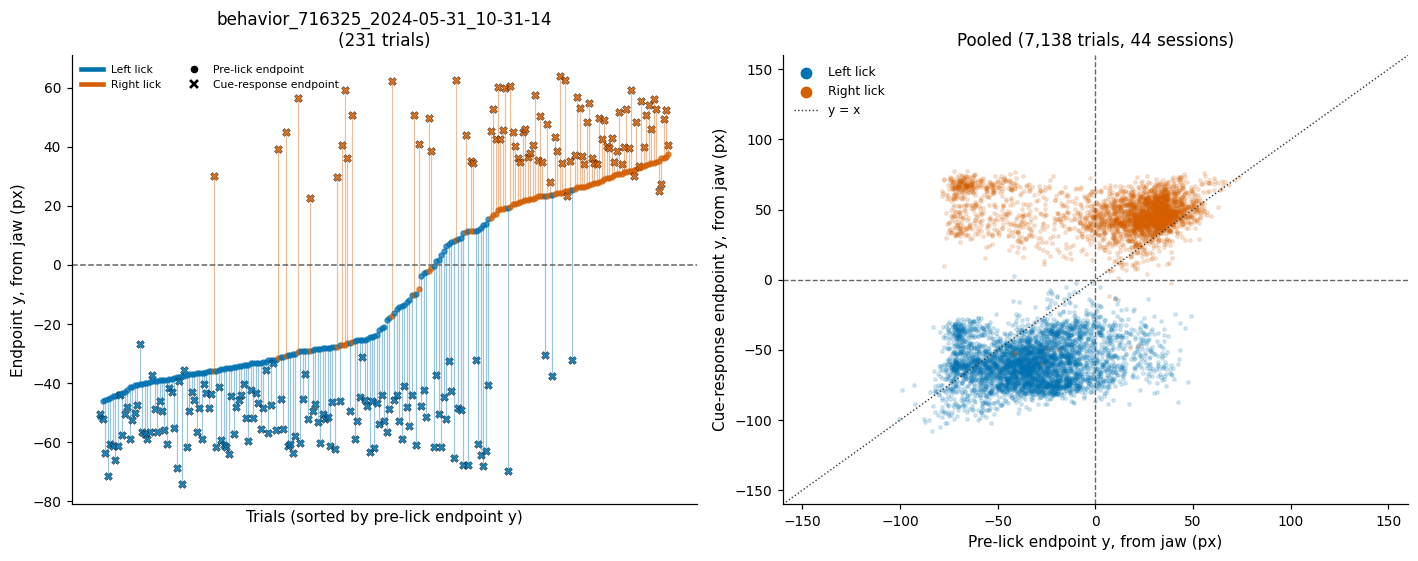

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Left: per-trial displacement for one session, trials sorted by pre-lick endpoint y
# (cueresponse cell 51). One session only — the per-trial view is unreadable at 7k trials.
# Reuse EXAMPLE_SESSION (§3's landmark-frame session, also the source notebook's own
# session) rather than picking by trial count, so one example recurs through the notebook.
example = EXAMPLE_SESSION
sess_pairs = paired_endpoints[paired_endpoints["session"] == example].sort_values("endpoint_y_rel")
for i, (_, row) in enumerate(sess_pairs.iterrows()):
    c = SIDE_COLOR[row["event"]]
    axes[0].plot([i, i], [row["endpoint_y_rel"], row["cue_y_rel"]], color=c, alpha=0.4, lw=0.8)
    axes[0].scatter(i, row["endpoint_y_rel"], color=c, s=10, alpha=0.7)
    axes[0].scatter(i, row["cue_y_rel"], color=c, s=26, marker="X",
                    edgecolor="k", linewidths=0.3, alpha=0.85)
axes[0].axhline(0, color=PALETTE["neutral"], ls="--", lw=1)
axes[0].set(xticks=[], xlabel="Trials (sorted by pre-lick endpoint y)",
            ylabel="Endpoint y, from jaw (px)",
            title="{}\n({:,} trials)".format(example, len(sess_pairs)))
axes[0].legend(handles=[Line2D([0], [0], color=SIDE_COLOR[s], lw=3, label=SIDE_LABEL[s]) for s in sides]
               + [Line2D([0], [0], marker="o", color="w", markerfacecolor="k", markersize=6,
                         linestyle="None", label="Pre-lick endpoint"),
                  Line2D([0], [0], marker="X", color="w", markerfacecolor="k", markersize=8,
                         linestyle="None", label="Cue-response endpoint")], fontsize=7, ncol=2)
style_ax(axes[0])

# Right: pooled — pre-lick vs cue-response endpoint y, all sessions, jaw at the origin.
for side in sides:
    sub = paired_endpoints[paired_endpoints["event"] == side]
    axes[1].scatter(sub["endpoint_y_rel"], sub["cue_y_rel"], s=5, alpha=0.15,
                    color=SIDE_COLOR[side], label=SIDE_LABEL[side], rasterized=True)
axes[1].axhline(0, color=PALETTE["neutral"], ls="--", lw=0.9)
axes[1].axvline(0, color=PALETTE["neutral"], ls="--", lw=0.9)
lim = 160
axes[1].plot([-lim, lim], [-lim, lim], color=PALETTE["all"], ls=":", lw=0.9, label="y = x")
axes[1].set(xlim=(-lim, lim), ylim=(-lim, lim),
            xlabel="Pre-lick endpoint y, from jaw (px)",
            ylabel="Cue-response endpoint y, from jaw (px)",
            title="Pooled ({:,} trials, {} sessions)".format(
                len(paired_endpoints), paired_endpoints["session"].nunique()))
leg = axes[1].legend(fontsize=8, markerscale=3)
for handle in leg.legend_handles:
    handle.set_alpha(1)
style_ax(axes[1])

plt.tight_layout()
save_fig(fig, "prelick_to_cue_displacement", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

/tmp/ipykernel_8353/1542697399.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


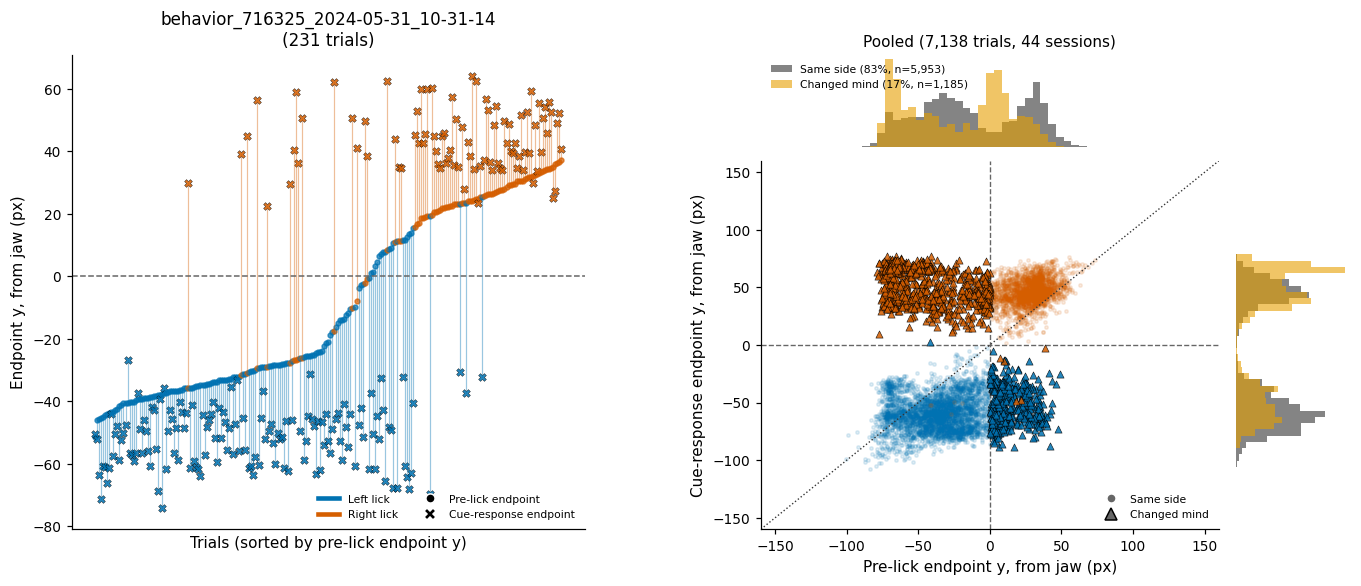

pre-lick |y|     changed-mind median  29.47 px (n=1,185)  vs  same-side median  32.45 px (n=5,953)  Mann-Whitney p = 0.00166
cue-response |y| changed-mind median  52.79 px (n=1,185)  vs  same-side median  54.30 px (n=5,953)  Mann-Whitney p = 1.64e-06


In [47]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 5.6))
outer = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.15], wspace=0.32)

# ---- Left panel: unchanged, just retargeted onto ax_left ----
ax_left = fig.add_subplot(outer[0])
example = EXAMPLE_SESSION
sess_pairs = paired_endpoints[paired_endpoints["session"] == example].sort_values("endpoint_y_rel")
for i, (_, row) in enumerate(sess_pairs.iterrows()):
    c = SIDE_COLOR[row["event"]]
    ax_left.plot([i, i], [row["endpoint_y_rel"], row["cue_y_rel"]], color=c, alpha=0.4, lw=0.8)
    ax_left.scatter(i, row["endpoint_y_rel"], color=c, s=10, alpha=0.7)
    ax_left.scatter(i, row["cue_y_rel"], color=c, s=26, marker="X",
                     edgecolor="k", linewidths=0.3, alpha=0.85)
ax_left.axhline(0, color=PALETTE["neutral"], ls="--", lw=1)
ax_left.set(xticks=[], xlabel="Trials (sorted by pre-lick endpoint y)",
            ylabel="Endpoint y, from jaw (px)",
            title="{}\n({:,} trials)".format(example, len(sess_pairs)))
ax_left.legend(handles=[Line2D([0], [0], color=SIDE_COLOR[s], lw=3, label=SIDE_LABEL[s]) for s in sides]
               + [Line2D([0], [0], marker="o", color="w", markerfacecolor="k", markersize=6,
                         linestyle="None", label="Pre-lick endpoint"),
                  Line2D([0], [0], marker="X", color="w", markerfacecolor="k", markersize=8,
                         linestyle="None", label="Cue-response endpoint")], fontsize=7, ncol=2)
style_ax(ax_left)

# ---- Right panel: joint scatter + marginals, split stayed vs. changed-mind ----
right = outer[1].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                              wspace=0.06, hspace=0.06)
ax_sc  = fig.add_subplot(right[1, 0])
ax_top = fig.add_subplot(right[0, 0], sharex=ax_sc)
ax_rt  = fig.add_subplot(right[1, 1], sharey=ax_sc)

n_stayed  = paired_endpoints["same_side"].sum()
n_changed = (~paired_endpoints["same_side"]).sum()
GROUP_COLOR = {"stayed": PALETTE["all"], "changed": PALETTE["sig"]}
GROUP_LABEL = {"stayed":  "Same side ({:.0%}, n={:,})".format(n_stayed / len(paired_endpoints), n_stayed),
               "changed": "Changed mind ({:.0%}, n={:,})".format(n_changed / len(paired_endpoints), n_changed)}

# Main scatter: lick-side color kept for context; changed-mind trials drawn larger/edged
# and on top, so they're visible against the much denser same-side cloud.
lim = 160
for side in sides:
    sub = paired_endpoints[paired_endpoints["event"] == side]
    stayed, flipped = sub[sub["same_side"]], sub[~sub["same_side"]]
    ax_sc.scatter(stayed["endpoint_y_rel"], stayed["cue_y_rel"], s=5, alpha=0.12,
                  color=SIDE_COLOR[side], rasterized=True, zorder=2)
    ax_sc.scatter(flipped["endpoint_y_rel"], flipped["cue_y_rel"], s=22, alpha=0.85,
                  color=SIDE_COLOR[side], edgecolor="k", linewidths=0.4, marker="^",
                  zorder=3, rasterized=True)
ax_sc.axhline(0, color=PALETTE["neutral"], ls="--", lw=0.9)
ax_sc.axvline(0, color=PALETTE["neutral"], ls="--", lw=0.9)
ax_sc.plot([-lim, lim], [-lim, lim], color=PALETTE["all"], ls=":", lw=0.9)
ax_sc.set(xlim=(-lim, lim), ylim=(-lim, lim),
          xlabel="Pre-lick endpoint y, from jaw (px)",
          ylabel="Cue-response endpoint y, from jaw (px)")
ax_sc.legend(handles=[Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE["neutral"],
                              markersize=6, linestyle="None", label="Same side"),
                       Line2D([0], [0], marker="^", color="w", markerfacecolor=PALETTE["neutral"],
                              markeredgecolor="k", markersize=8, linestyle="None",
                              label="Changed mind")], fontsize=7, loc="lower right")
style_ax(ax_sc)

# Marginals: pre-lick y on top, cue-response y on the right — this is the actual test.
bins = np.linspace(-lim, lim, 60)
for mask, key in [(paired_endpoints["same_side"], "stayed"), (~paired_endpoints["same_side"], "changed")]:
    ax_top.hist(paired_endpoints.loc[mask, "endpoint_y_rel"], bins=bins, density=True,
                color=GROUP_COLOR[key], alpha=0.6, label=GROUP_LABEL[key])
    ax_rt.hist(paired_endpoints.loc[mask, "cue_y_rel"], bins=bins, density=True,
               orientation="horizontal", color=GROUP_COLOR[key], alpha=0.6)
ax_top.axis("off")
ax_rt.axis("off")
ax_top.legend(fontsize=7, loc="upper left", frameon=False)
ax_top.set_title("Pooled ({:,} trials, {} sessions)".format(
    len(paired_endpoints), paired_endpoints["session"].nunique()), fontsize=10)

plt.tight_layout()
save_fig(fig, "prelick_to_cue_displacement_marginals_density", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

# Quantify "separate distribution" rather than leaving it to the eye: changed-mind trials
# should sit closer to the midline pre-lick (weaker initial commitment) if the story holds.
for col, label in [("endpoint_y_rel", "pre-lick |y|"), ("cue_y_rel", "cue-response |y|")]:
    changed_vals = paired_endpoints.loc[~paired_endpoints["same_side"], col].abs()
    stayed_vals  = paired_endpoints.loc[paired_endpoints["same_side"], col].abs()
    u = stats.mannwhitneyu(changed_vals, stayed_vals)
    print("{:<16s} changed-mind median {:6.2f} px (n={:,})  vs  same-side median {:6.2f} px (n={:,})  "
          "Mann-Whitney p {}".format(label, changed_vals.median(), len(changed_vals),
                                     stayed_vals.median(), len(stayed_vals), fmt_p(u.pvalue)))



left_lick_time   same-side median  -35.89 px (n=3,704)   changed-mind median   10.96 px (n=431)   Mann-Whitney p = 2.44e-252
right_lick_time  same-side median   29.43 px (n=2,249)   changed-mind median  -50.21 px (n=754)   Mann-Whitney p < 1e-300


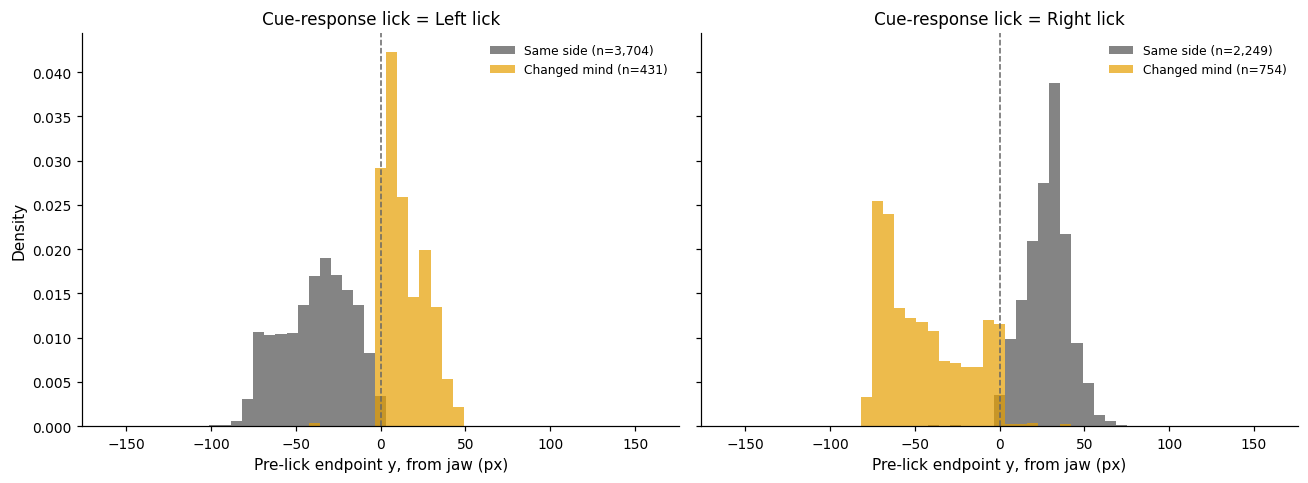

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

bins = np.linspace(-160, 160, 50)
for ax, side in zip(axes, ["left_lick_time", "right_lick_time"]):
    sub = paired_endpoints[paired_endpoints["event"] == side]
    stayed  = sub.loc[sub["same_side"], "endpoint_y_rel"]
    changed = sub.loc[~sub["same_side"], "endpoint_y_rel"]

    ax.hist(stayed, bins=bins, density=True, color=PALETTE["all"], alpha=0.6,
            label="Same side (n={:,})".format(len(stayed)))
    ax.hist(changed, bins=bins, density=True, color=PALETTE["sig"], alpha=0.7,
            label="Changed mind (n={:,})".format(len(changed)))
    ax.axvline(0, color=PALETTE["neutral"], ls="--", lw=1)
    ax.set(xlabel="Pre-lick endpoint y, from jaw (px)",
           title="Cue-response lick = {}".format(SIDE_LABEL[side]))
    ax.legend(fontsize=8)
    style_ax(ax)

    u = stats.mannwhitneyu(changed, stayed)
    print("{:<16s} same-side median {:7.2f} px (n={:,})   changed-mind median {:7.2f} px (n={:,})   "
          "Mann-Whitney p {}".format(side, stayed.median(), len(stayed),
                                     changed.median(), len(changed), fmt_p(u.pvalue)))

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()


/tmp/ipykernel_8353/73493827.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


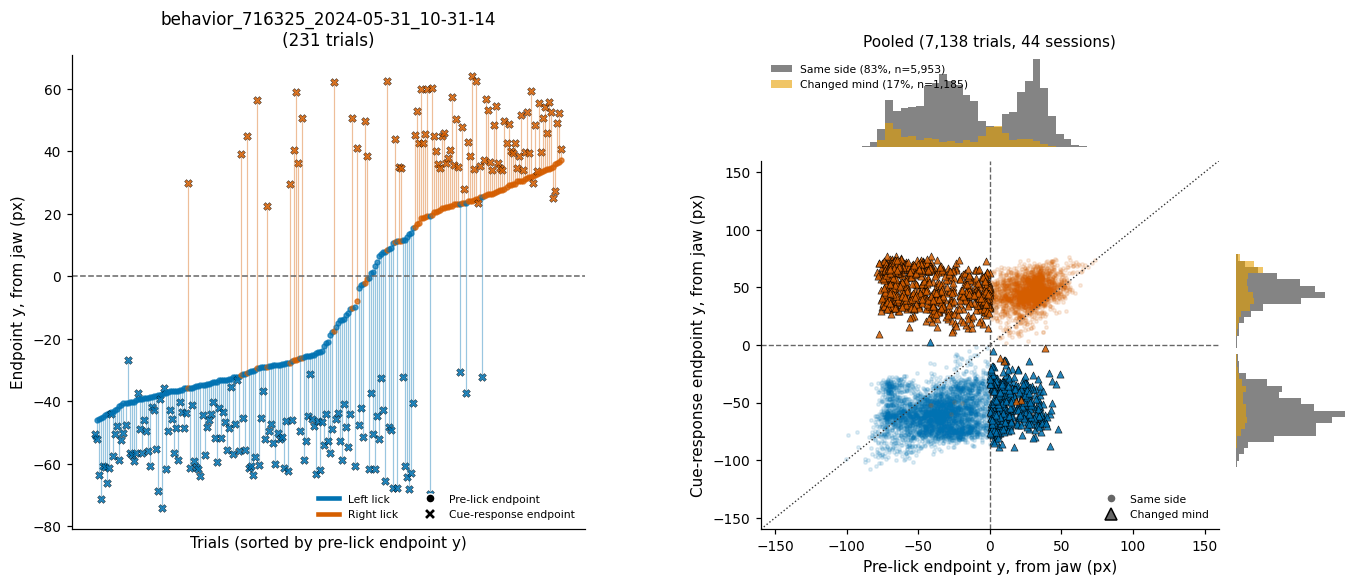

pre-lick |y|     changed-mind median  29.47 px (n=1,185)  vs  same-side median  32.45 px (n=5,953)  Mann-Whitney p = 0.00166
cue-response |y| changed-mind median  52.79 px (n=1,185)  vs  same-side median  54.30 px (n=5,953)  Mann-Whitney p = 1.64e-06


In [50]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 5.6))
outer = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.15], wspace=0.32)

# ---- Left panel: unchanged, just retargeted onto ax_left ----
ax_left = fig.add_subplot(outer[0])
example = EXAMPLE_SESSION
sess_pairs = paired_endpoints[paired_endpoints["session"] == example].sort_values("endpoint_y_rel")
for i, (_, row) in enumerate(sess_pairs.iterrows()):
    c = SIDE_COLOR[row["event"]]
    ax_left.plot([i, i], [row["endpoint_y_rel"], row["cue_y_rel"]], color=c, alpha=0.4, lw=0.8)
    ax_left.scatter(i, row["endpoint_y_rel"], color=c, s=10, alpha=0.7)
    ax_left.scatter(i, row["cue_y_rel"], color=c, s=26, marker="X",
                     edgecolor="k", linewidths=0.3, alpha=0.85)
ax_left.axhline(0, color=PALETTE["neutral"], ls="--", lw=1)
ax_left.set(xticks=[], xlabel="Trials (sorted by pre-lick endpoint y)",
            ylabel="Endpoint y, from jaw (px)",
            title="{}\n({:,} trials)".format(example, len(sess_pairs)))
ax_left.legend(handles=[Line2D([0], [0], color=SIDE_COLOR[s], lw=3, label=SIDE_LABEL[s]) for s in sides]
               + [Line2D([0], [0], marker="o", color="w", markerfacecolor="k", markersize=6,
                         linestyle="None", label="Pre-lick endpoint"),
                  Line2D([0], [0], marker="X", color="w", markerfacecolor="k", markersize=8,
                         linestyle="None", label="Cue-response endpoint")], fontsize=7, ncol=2)
style_ax(ax_left)

# ---- Right panel: joint scatter + marginals, split stayed vs. changed-mind ----
right = outer[1].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                              wspace=0.06, hspace=0.06)
ax_sc  = fig.add_subplot(right[1, 0])
ax_top = fig.add_subplot(right[0, 0], sharex=ax_sc)
ax_rt  = fig.add_subplot(right[1, 1], sharey=ax_sc)

n_stayed  = paired_endpoints["same_side"].sum()
n_changed = (~paired_endpoints["same_side"]).sum()
GROUP_COLOR = {"stayed": PALETTE["all"], "changed": PALETTE["sig"]}
GROUP_LABEL = {"stayed":  "Same side ({:.0%}, n={:,})".format(n_stayed / len(paired_endpoints), n_stayed),
               "changed": "Changed mind ({:.0%}, n={:,})".format(n_changed / len(paired_endpoints), n_changed)}

# Main scatter: lick-side color kept for context; changed-mind trials drawn larger/edged
# and on top, so they're visible against the much denser same-side cloud.
lim = 160
for side in sides:
    sub = paired_endpoints[paired_endpoints["event"] == side]
    stayed, flipped = sub[sub["same_side"]], sub[~sub["same_side"]]
    ax_sc.scatter(stayed["endpoint_y_rel"], stayed["cue_y_rel"], s=5, alpha=0.12,
                  color=SIDE_COLOR[side], rasterized=True, zorder=2)
    ax_sc.scatter(flipped["endpoint_y_rel"], flipped["cue_y_rel"], s=22, alpha=0.85,
                  color=SIDE_COLOR[side], edgecolor="k", linewidths=0.4, marker="^",
                  zorder=3, rasterized=True)
ax_sc.axhline(0, color=PALETTE["neutral"], ls="--", lw=0.9)
ax_sc.axvline(0, color=PALETTE["neutral"], ls="--", lw=0.9)
ax_sc.plot([-lim, lim], [-lim, lim], color=PALETTE["all"], ls=":", lw=0.9)
ax_sc.set(xlim=(-lim, lim), ylim=(-lim, lim),
          xlabel="Pre-lick endpoint y, from jaw (px)",
          ylabel="Cue-response endpoint y, from jaw (px)")
ax_sc.legend(handles=[Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE["neutral"],
                              markersize=6, linestyle="None", label="Same side"),
                       Line2D([0], [0], marker="^", color="w", markerfacecolor=PALETTE["neutral"],
                              markeredgecolor="k", markersize=8, linestyle="None",
                              label="Changed mind")], fontsize=7, loc="lower right")
style_ax(ax_sc)

# Marginals: raw counts, not density — same-side (n=5,953) will dwarf changed-mind
# (n=1,185) in absolute height, which is the actual prevalence difference, not just shape.
bins = np.linspace(-lim, lim, 60)
for mask, key in [(paired_endpoints["same_side"], "stayed"), (~paired_endpoints["same_side"], "changed")]:
    ax_top.hist(paired_endpoints.loc[mask, "endpoint_y_rel"], bins=bins,
                color=GROUP_COLOR[key], alpha=0.6, label=GROUP_LABEL[key])
    ax_rt.hist(paired_endpoints.loc[mask, "cue_y_rel"], bins=bins,
               orientation="horizontal", color=GROUP_COLOR[key], alpha=0.6)
ax_top.axis("off")
ax_rt.axis("off")
ax_top.legend(fontsize=7, loc="upper left", frameon=False)
ax_top.set_title("Pooled ({:,} trials, {} sessions)".format(
    len(paired_endpoints), paired_endpoints["session"].nunique()), fontsize=10)

plt.tight_layout()
save_fig(fig, "prelick_to_cue_displacement_marginals_counts", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

# Quantify "separate distribution" rather than leaving it to the eye: changed-mind trials
# should sit closer to the midline pre-lick (weaker initial commitment) if the story holds.
for col, label in [("endpoint_y_rel", "pre-lick |y|"), ("cue_y_rel", "cue-response |y|")]:
    changed_vals = paired_endpoints.loc[~paired_endpoints["same_side"], col].abs()
    stayed_vals  = paired_endpoints.loc[paired_endpoints["same_side"], col].abs()
    u = stats.mannwhitneyu(changed_vals, stayed_vals)
    print("{:<16s} changed-mind median {:6.2f} px (n={:,})  vs  same-side median {:6.2f} px (n={:,})  "
          "Mann-Whitney p {}".format(label, changed_vals.median(), len(changed_vals),
                                     stayed_vals.median(), len(stayed_vals), fmt_p(u.pvalue)))


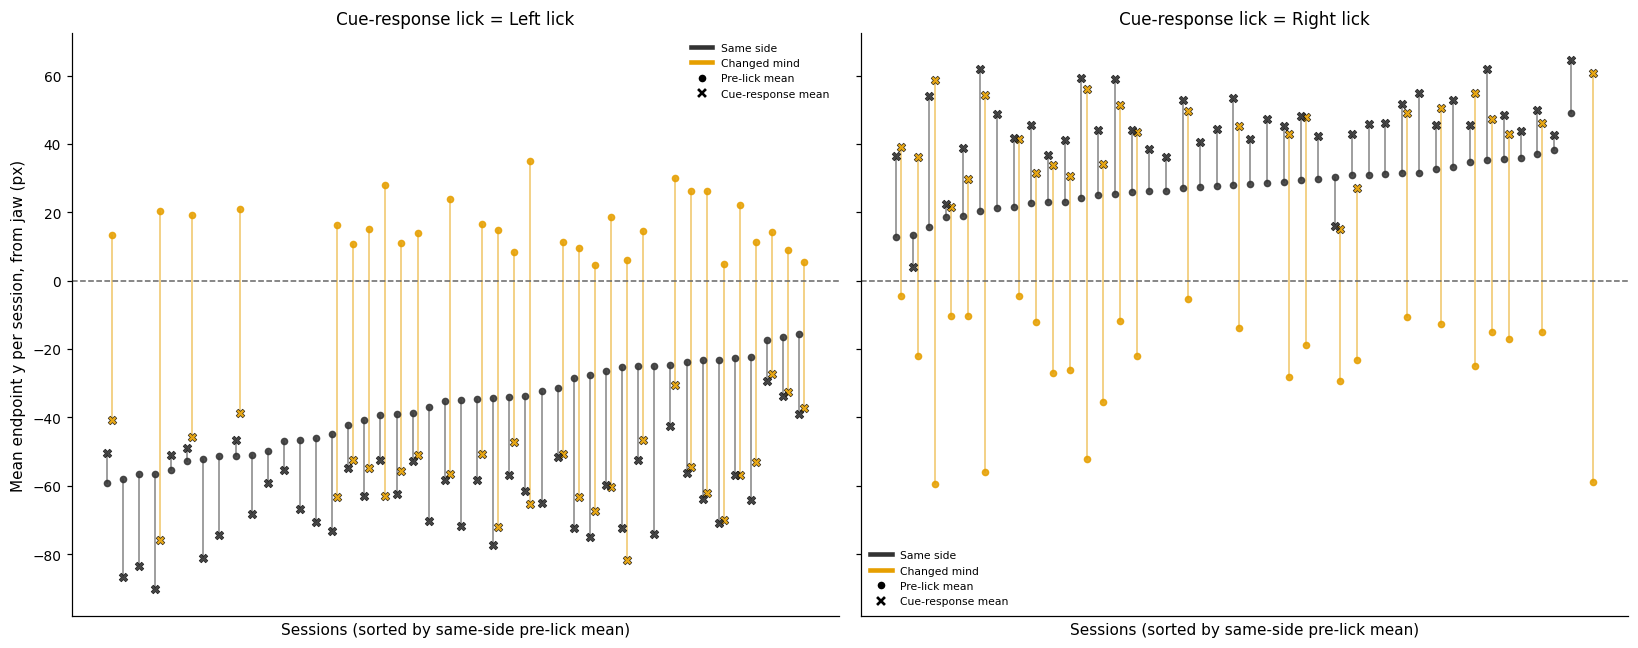

                           mean_pre  sem_pre  mean_cue  sem_cue  n_sessions
event           same_side                                                  
left_lick_time  False         16.03     1.43    -54.31     2.43          30
                True         -37.14     1.90    -61.98     2.02          44
right_lick_time False        -23.24     3.13     42.23     2.22          27
                True          27.72     1.10     44.88     1.79          41

Asymmetry (session-mean |pre-lick y|):
  same-side:    |left| 37.14  vs  |right| 27.72   diff +9.42
  changed-mind: |left| 16.03  vs  |right| 23.24   diff -7.21


In [52]:
summary = (paired_endpoints
           .groupby(["session", "event", "same_side"])
           .agg(pre_mean=("endpoint_y_rel", "mean"),
                cue_mean=("cue_y_rel", "mean"),
                n=("endpoint_y_rel", "size"))
           .reset_index())

MIN_N = 3  # per-session, per-group minimum trial count to plot/summarize a point

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
STATUS_COLOR = {True: PALETTE["all"], False: PALETTE["sig"]}

for ax, side in zip(axes, ["left_lick_time", "right_lick_time"]):
    side_summary = summary[(summary["event"] == side) & (summary["n"] >= MIN_N)]

    # order sessions by that session's same-side pre-lick mean, for a readable sweep;
    # sessions missing a qualifying same-side row (rare) sort to the end
    order_key = (side_summary[side_summary["same_side"]]
                 .set_index("session")["pre_mean"]
                 .reindex(side_summary["session"].unique()))
    order = order_key.sort_values(na_position="last").index.tolist()
    x_pos = {s: i for i, s in enumerate(order)}

    for same_side, grp in side_summary.groupby("same_side"):
        offset = -0.15 if same_side else 0.15
        color = STATUS_COLOR[same_side]
        for _, row in grp.iterrows():
            x = x_pos[row["session"]] + offset
            ax.plot([x, x], [row["pre_mean"], row["cue_mean"]], color=color, alpha=0.6, lw=1)
            ax.scatter(x, row["pre_mean"], color=color, s=16, alpha=0.85, zorder=3)
            ax.scatter(x, row["cue_mean"], color=color, s=32, marker="X", edgecolor="k",
                       linewidths=0.4, alpha=0.9, zorder=3)

    ax.axhline(0, color=PALETTE["neutral"], ls="--", lw=1)
    ax.set(xticks=[], xlabel="Sessions (sorted by same-side pre-lick mean)",
           title="Cue-response lick = {}".format(SIDE_LABEL[side]))
    ax.legend(handles=[
        Line2D([0], [0], color=STATUS_COLOR[True], lw=3, label="Same side"),
        Line2D([0], [0], color=STATUS_COLOR[False], lw=3, label="Changed mind"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="k", markersize=6,
               linestyle="None", label="Pre-lick mean"),
        Line2D([0], [0], marker="X", color="w", markerfacecolor="k", markersize=8,
               linestyle="None", label="Cue-response mean"),
    ], fontsize=7, loc="best")
    style_ax(ax)

axes[0].set_ylabel("Mean endpoint y per session, from jaw (px)")
plt.tight_layout()
save_fig(fig, "session_endpoints_by_side_and_switch", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

# Pooled (session as sampling unit) numbers behind the plot.
pooled = (summary[summary["n"] >= MIN_N]
          .groupby(["event", "same_side"])
          .agg(mean_pre=("pre_mean", "mean"),
               sem_pre=("pre_mean", lambda s: s.std(ddof=1) / np.sqrt(len(s))),
               mean_cue=("cue_mean", "mean"),
               sem_cue=("cue_mean", lambda s: s.std(ddof=1) / np.sqrt(len(s))),
               n_sessions=("pre_mean", "size")))
print(pooled.to_string(float_format=lambda v: "{:6.2f}".format(v)))

# Direct asymmetry check: does |left| > |right| show up the same way in same-side and
# changed-mind pre-lick positions, or is it specific to one group?
same_left, same_right = pooled.loc[("left_lick_time", True)], pooled.loc[("right_lick_time", True)]
chg_left,  chg_right  = pooled.loc[("left_lick_time", False)], pooled.loc[("right_lick_time", False)]
print("\nAsymmetry (session-mean |pre-lick y|):")
print("  same-side:    |left| {:.2f}  vs  |right| {:.2f}   diff {:+.2f}".format(
    abs(same_left["mean_pre"]), abs(same_right["mean_pre"]),
    abs(same_left["mean_pre"]) - abs(same_right["mean_pre"])))
print("  changed-mind: |left| {:.2f}  vs  |right| {:.2f}   diff {:+.2f}".format(
    abs(chg_left["mean_pre"]), abs(chg_right["mean_pre"]),
    abs(chg_left["mean_pre"]) - abs(chg_right["mean_pre"])))


cmp  group A       n     mean   group B       n     mean   Mann-Whitney p
1a   Stay L     3704   -37.86   Switch→L    431    14.43   = 2.44e-252
1b   Stay R     2249    27.98   Switch→R    754   -44.04   < 1e-300
2a   Stay L     3704   -37.86   Switch→R    754   -44.04   = 2.71e-14
2b   Stay R     2249    27.98   Switch→L    431    14.43   = 1.35e-78
3a   Stay L     3704   -59.52   Switch→L    431   -52.69   = 2.82e-15
3b   Stay R     2249    46.10   Switch→R    754    50.68   = 2.12e-14
4a   Stay L     3704   -59.52   Switch→R    754    50.68   < 1e-300
4b   Stay R     2249    46.10   Switch→L    431   -52.69   = 6.84e-237


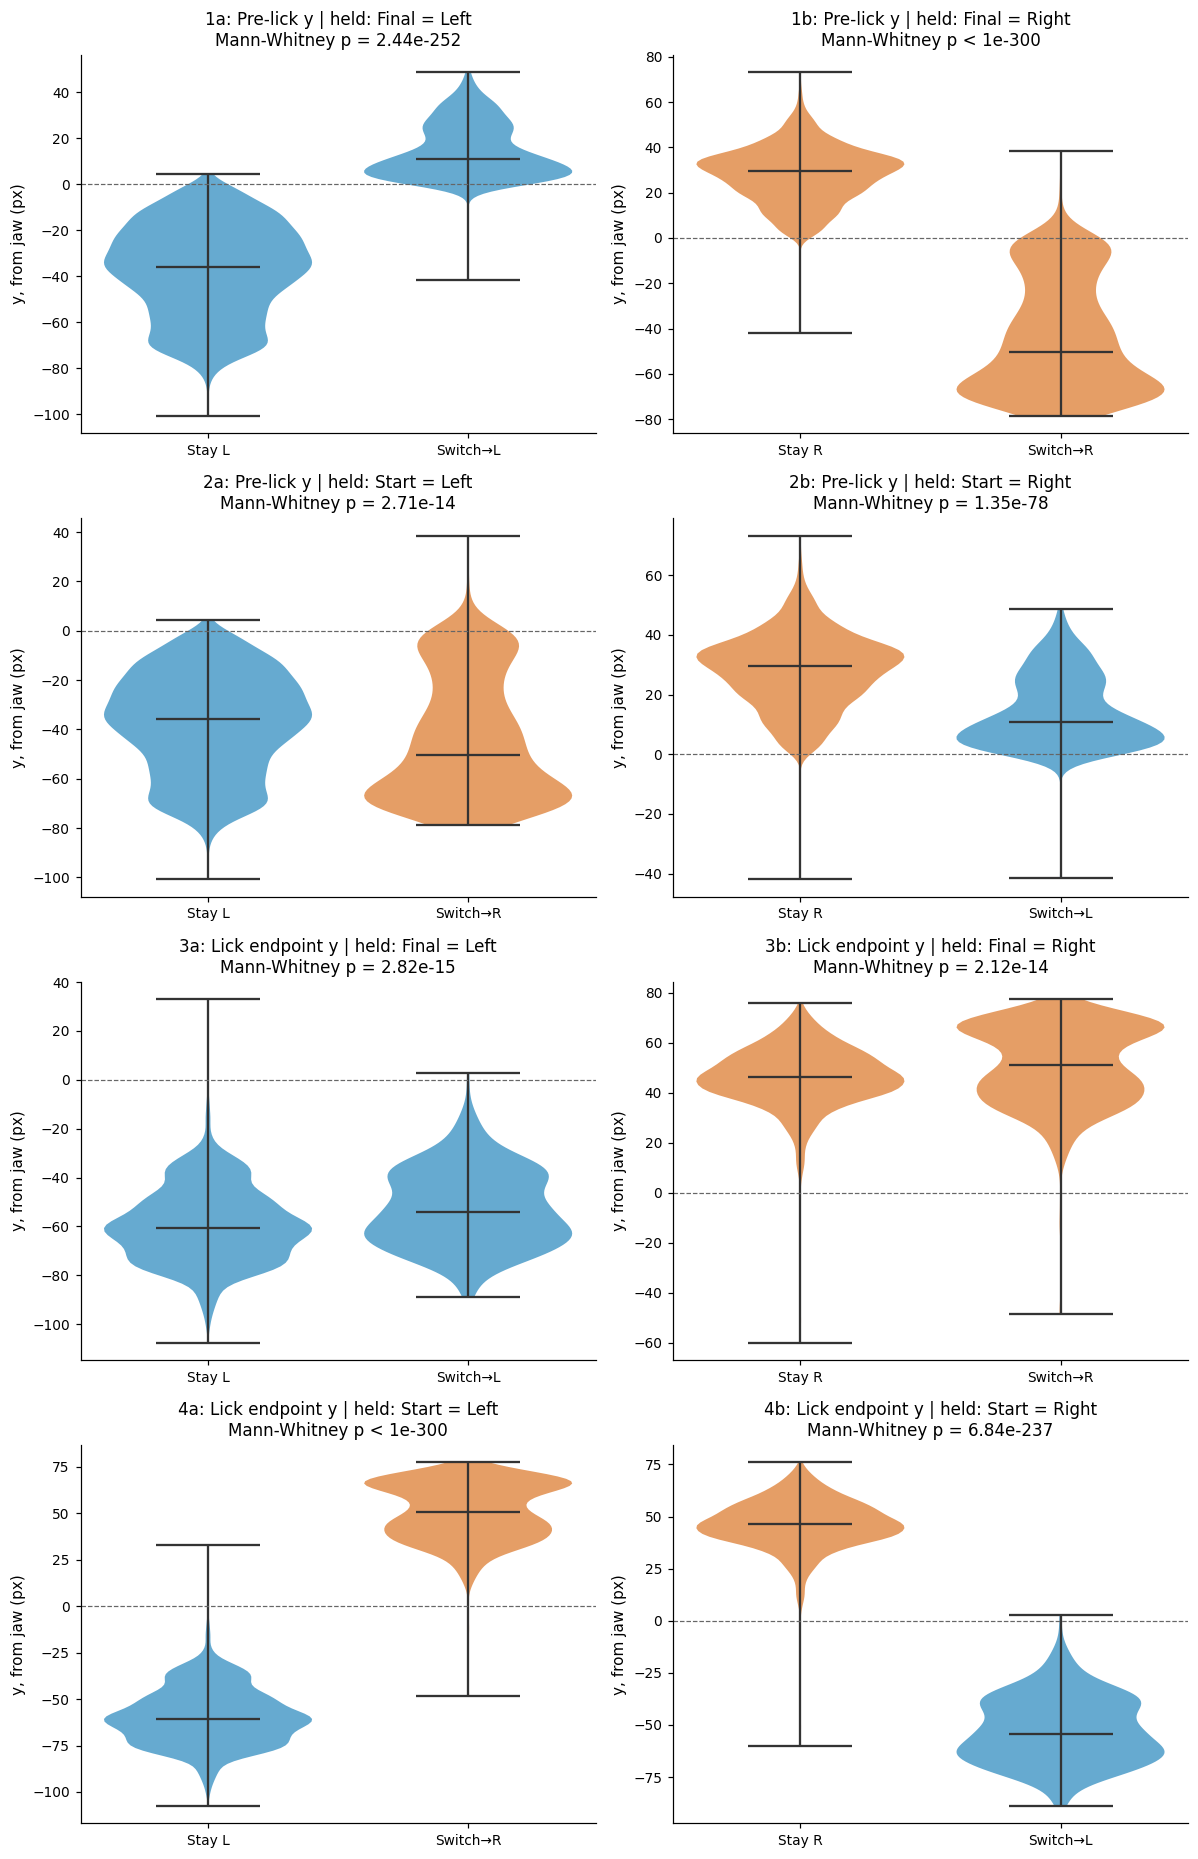

In [53]:
A = paired_endpoints[(paired_endpoints["event"] == "left_lick_time")  & paired_endpoints["same_side"]]
B = paired_endpoints[(paired_endpoints["event"] == "right_lick_time") & paired_endpoints["same_side"]]
C = paired_endpoints[(paired_endpoints["event"] == "left_lick_time")  & ~paired_endpoints["same_side"]]
D = paired_endpoints[(paired_endpoints["event"] == "right_lick_time") & ~paired_endpoints["same_side"]]

GROUP_DF    = {"A": A, "B": B, "C": C, "D": D}
GROUP_LABEL = {"A": "Stay L", "B": "Stay R", "C": "Switch\u2192L", "D": "Switch\u2192R"}
GROUP_COLOR = {"A": PALETTE["neg"], "C": PALETTE["neg"], "B": PALETTE["pos"], "D": PALETTE["pos"]}  # by final side

COMPARISONS = [
    ("1a", "endpoint_y_rel", "A", "C", "Pre-lick y | held: Final = Left"),
    ("1b", "endpoint_y_rel", "B", "D", "Pre-lick y | held: Final = Right"),
    ("2a", "endpoint_y_rel", "A", "D", "Pre-lick y | held: Start = Left"),
    ("2b", "endpoint_y_rel", "B", "C", "Pre-lick y | held: Start = Right"),
    ("3a", "cue_y_rel",      "A", "C", "Lick endpoint y | held: Final = Left"),
    ("3b", "cue_y_rel",      "B", "D", "Lick endpoint y | held: Final = Right"),
    ("4a", "cue_y_rel",      "A", "D", "Lick endpoint y | held: Start = Left"),
    ("4b", "cue_y_rel",      "B", "C", "Lick endpoint y | held: Start = Right"),
]

fig, axes = plt.subplots(4, 2, figsize=(11, 17))
print("{:4s} {:9s}{:>6s}{:>9s}   {:9s}{:>6s}{:>9s}   {}".format(
    "cmp", "group A", "n", "mean", "group B", "n", "mean", "Mann-Whitney p"))

for ax, (tag, col, ka, kb, title) in zip(axes.ravel(), COMPARISONS):
    a_vals, b_vals = GROUP_DF[ka][col], GROUP_DF[kb][col]

    parts = ax.violinplot([a_vals, b_vals], positions=[0, 1], showmedians=True, widths=0.8)
    for body, k in zip(parts["bodies"], [ka, kb]):
        body.set_facecolor(GROUP_COLOR[k])
        body.set_alpha(0.6)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[key].set_color(PALETTE["all"])

    ax.axhline(0, color=PALETTE["neutral"], ls="--", lw=0.8)
    u = stats.mannwhitneyu(a_vals, b_vals)
    ax.set(xticks=[0, 1], xticklabels=[GROUP_LABEL[ka], GROUP_LABEL[kb]],
           ylabel="y, from jaw (px)",
           title="{}: {}\nMann-Whitney p {}".format(tag, title, fmt_p(u.pvalue)))
    style_ax(ax)

    print("{:4s} {:9s}{:6d}{:9.2f}   {:9s}{:6d}{:9.2f}   {}".format(
        tag, GROUP_LABEL[ka], len(a_vals), a_vals.mean(),
        GROUP_LABEL[kb], len(b_vals), b_vals.mean(), fmt_p(u.pvalue)))

plt.tight_layout()
save_fig(fig, "switch_stay_comparison_grid", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()


cmp  group A        mean   group B        mean   n_sess   Wilcoxon p
2a   Stay L       -39.76   Switch→R     -25.82       18   = 0.00158
2b   Stay R        28.91   Switch→L      14.71       24   = 1.19e-07
3a   Stay L       -57.99   Switch→L     -53.81       25   = 0.000329
3b   Stay R        44.73   Switch→R      41.80       17   = 0.0267


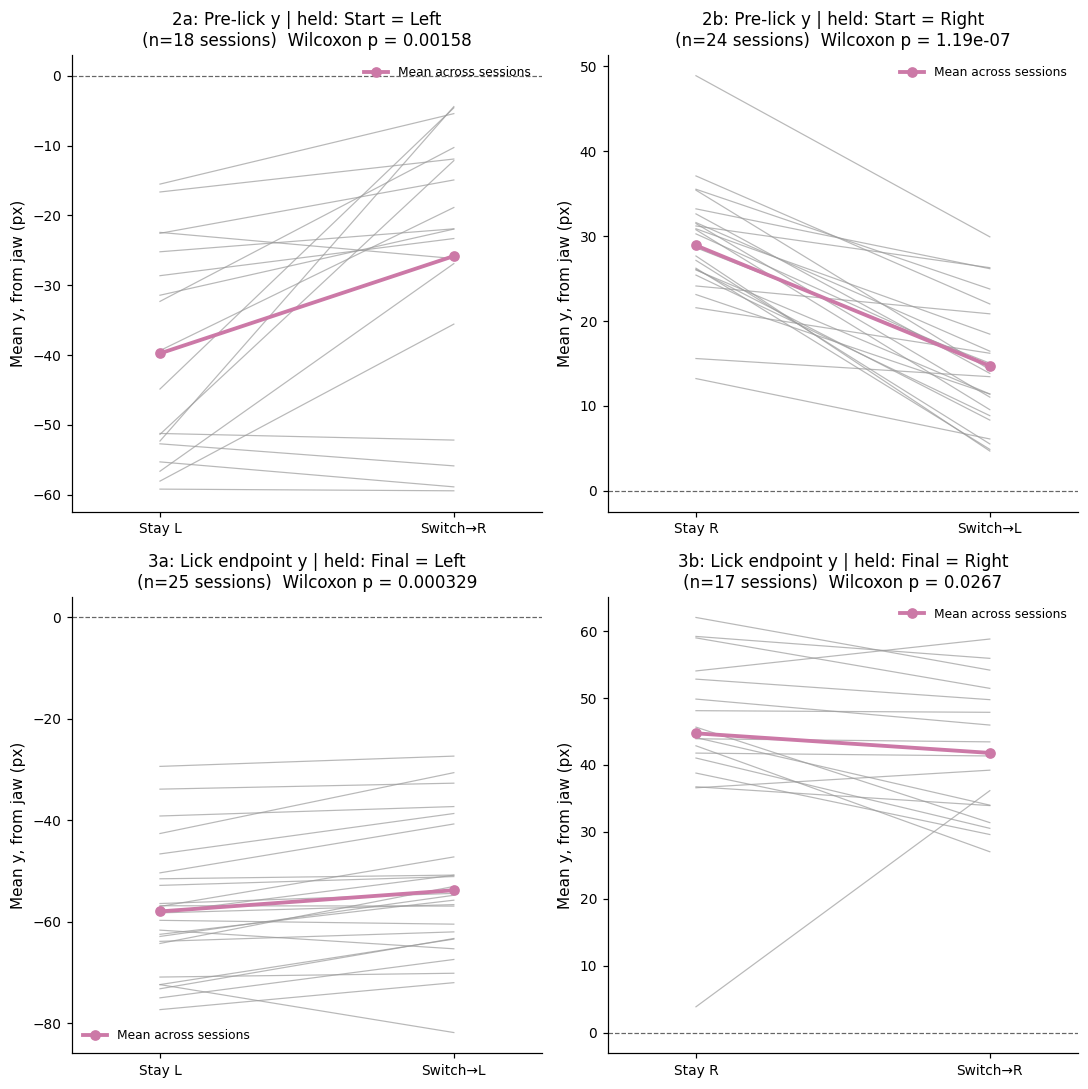

In [54]:
MIN_N = 5  # per-session, per-group minimum trial count to include that session's mean

def session_means(df, col, min_n=MIN_N):
    """Per-session mean of `col`, dropping sessions with too few trials to trust."""
    g = df.groupby("session")[col].agg(["mean", "size"])
    return g.loc[g["size"] >= min_n, "mean"]

COMPARISONS = [
    ("2a", "endpoint_y_rel", "A", "D", "Pre-lick y | held: Start = Left"),
    ("2b", "endpoint_y_rel", "B", "C", "Pre-lick y | held: Start = Right"),
    ("3a", "cue_y_rel",      "A", "C", "Lick endpoint y | held: Final = Left"),
    ("3b", "cue_y_rel",      "B", "D", "Lick endpoint y | held: Final = Right"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
print("{:4s} {:9s}{:>10s}   {:9s}{:>10s}   {:>6s}   {}".format(
    "cmp", "group A", "mean", "group B", "mean", "n_sess", "Wilcoxon p"))

for ax, (tag, col, ka, kb, title) in zip(axes.ravel(), COMPARISONS):
    a_means = session_means(GROUP_DF[ka], col)
    b_means = session_means(GROUP_DF[kb], col)
    shared = a_means.index.intersection(b_means.index)
    a_paired, b_paired = a_means.loc[shared], b_means.loc[shared]

    for s in shared:
        ax.plot([0, 1], [a_paired[s], b_paired[s]], color=PALETTE["not_sig"], lw=0.8, alpha=0.7)
    ax.plot([0, 1], [a_paired.mean(), b_paired.mean()], color=PALETTE["accent"],
            lw=2.5, marker="o", label="Mean across sessions")
    ax.axhline(0, color=PALETTE["neutral"], ls="--", lw=0.8)

    w = stats.wilcoxon(a_paired, b_paired)
    ax.set(xticks=[0, 1], xticklabels=[GROUP_LABEL[ka], GROUP_LABEL[kb]], xlim=(-0.3, 1.3),
           ylabel="Mean y, from jaw (px)",
           title="{}: {}\n(n={} sessions)  Wilcoxon p {}".format(tag, title, len(shared), fmt_p(w.pvalue)))
    ax.legend(fontsize=8)
    style_ax(ax)

    print("{:4s} {:9s}{:10.2f}   {:9s}{:10.2f}   {:6d}   {}".format(
        tag, GROUP_LABEL[ka], a_paired.mean(), GROUP_LABEL[kb], b_paired.mean(),
        len(shared), fmt_p(w.pvalue)))

plt.tight_layout()
save_fig(fig, "switch_stay_per_session_2_3", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()


/tmp/ipykernel_8353/1780153123.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


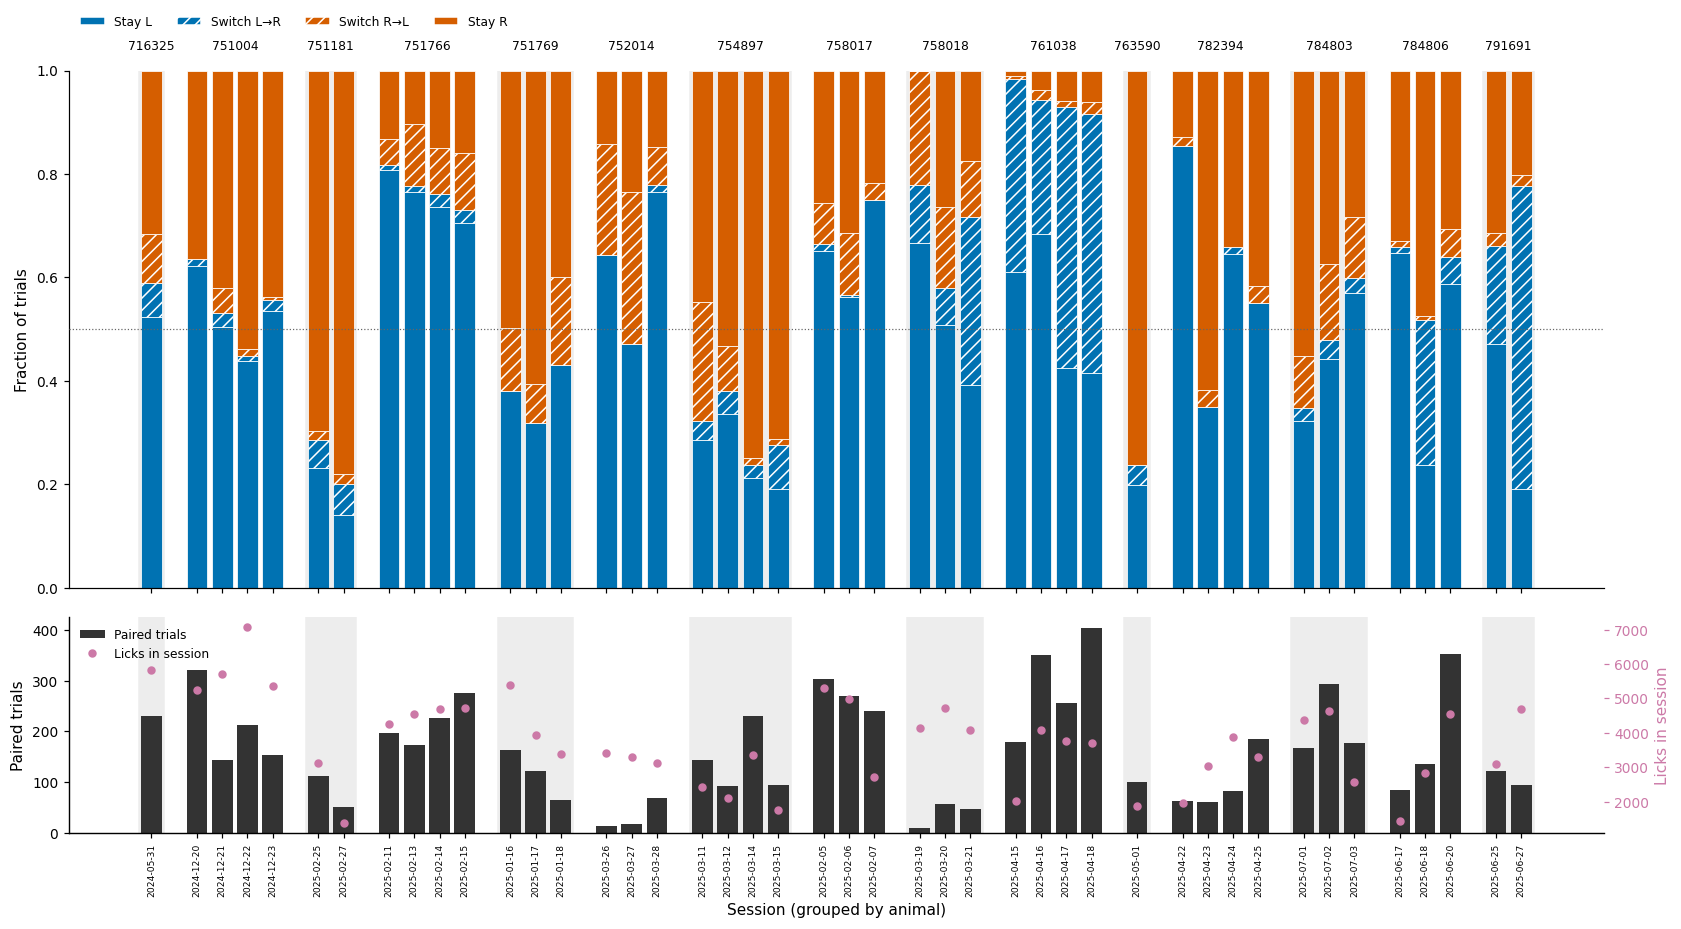

Switch fraction by animal:
subject
761038    0.428
791691    0.386
758018    0.321
716325    0.160
784803    0.158
752014    0.141
784806    0.136
754897    0.121
751769    0.114
751766    0.112
758017    0.085
751181    0.074
763590    0.040
751004    0.029
782394    0.026

Fraction of pre-licks starting RIGHT, by animal:
subject
761038    0.061
751766    0.231
791691    0.288
752014    0.293
758017    0.343
758018    0.357
784806    0.386
782394    0.409
716325    0.411
751004    0.445
784803    0.520
751769    0.631
754897    0.716
751181    0.741
763590    0.762


In [55]:
from matplotlib.patches import Patch  # add to §1 imports if not already there

pe = paired_endpoints.copy()
pe["subject"] = pe["session"].str.split("_").str[1]
pe["cat"] = np.where(pe["same_side"],
                     np.where(pe["event"] == "left_lick_time", "stay_L", "stay_R"),
                     np.where(pe["event"] == "left_lick_time", "switch_L", "switch_R"))

# Coloured by STARTING side (blue = pre-lick went left), hatched = switched.
# So total blue height per bar = fraction of trials that started leftward.
CATS   = ["stay_L", "switch_R", "switch_L", "stay_R"]
CLABEL = {"stay_L": "Stay L", "switch_R": "Switch L\u2192R",
          "switch_L": "Switch R\u2192L", "stay_R": "Stay R"}
CCOLOR = {"stay_L": PALETTE["neg"], "switch_R": PALETTE["neg"],
          "switch_L": PALETTE["pos"], "stay_R": PALETTE["pos"]}
CHATCH = {"stay_L": "", "switch_R": "///", "switch_L": "///", "stay_R": ""}

counts = pe.groupby(["session", "cat"]).size().unstack(fill_value=0).reindex(columns=CATS, fill_value=0)
props  = counts.div(counts.sum(axis=1), axis=0)
npair  = counts.sum(axis=1)
licks  = df.groupby("session")["lick_count"].sum()
subj   = pe.groupby("session")["subject"].first()

# x layout: sessions grouped by animal, gap between animals
order, xpos, blocks, x = [], {}, [], 0.0
for s_id in sorted(subj.unique()):
    start = x
    for sess_name in sorted(subj[subj == s_id].index):
        order.append(sess_name); xpos[sess_name] = x; x += 1
    blocks.append((s_id, start - 0.5, x - 0.5))
    x += 0.8
X = [xpos[s] for s in order]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(18, 9), sharex=True,
                                     gridspec_kw={"height_ratios": [2.4, 1], "hspace": 0.08})

for i, (s_id, x0, x1) in enumerate(blocks):
    if i % 2 == 0:
        for a in (ax_top, ax_bot):
            a.axvspan(x0, x1, color="0.93", zorder=0)
    ax_top.text((x0 + x1) / 2, 1.035, s_id, transform=ax_top.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=8)

bottom = np.zeros(len(order))
for c in CATS:
    vals = props.loc[order, c].values
    ax_top.bar(X, vals, bottom=bottom, width=0.82, color=CCOLOR[c], hatch=CHATCH[c],
               edgecolor="white", linewidth=0.5, zorder=2)
    bottom += vals
ax_top.axhline(0.5, color=PALETTE["neutral"], ls=":", lw=0.8, zorder=3)
ax_top.set(ylim=(0, 1), ylabel="Fraction of trials")
ax_top.legend(handles=[Patch(facecolor=CCOLOR[c], hatch=CHATCH[c], edgecolor="white",
                             label=CLABEL[c]) for c in CATS],
              fontsize=8, ncol=4, loc="lower left", bbox_to_anchor=(0, 1.06), frameon=False)
style_ax(ax_top)

ax_bot.bar(X, npair.loc[order].values, width=0.82, color=PALETTE["all"], zorder=2, label="Paired trials")
ax_bot.set(ylabel="Paired trials", xlabel="Session (grouped by animal)")
ax_lick = ax_bot.twinx()
ax_lick.plot(X, licks.loc[order].values, ls="none", marker="o", ms=4.5,
             color=PALETTE["accent"], zorder=3, label="Licks in session")
ax_lick.set_ylabel("Licks in session", color=PALETTE["accent"])
ax_lick.tick_params(axis="y", colors=PALETTE["accent"])
ax_lick.spines["top"].set_visible(False)
h1, l1 = ax_bot.get_legend_handles_labels(); h2, l2 = ax_lick.get_legend_handles_labels()
ax_bot.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
ax_bot.set_xticks(X)
ax_bot.set_xticklabels([s.split("_")[2] for s in order], rotation=90, fontsize=6)
style_ax(ax_bot)

plt.tight_layout()
save_fig(fig, "session_trial_category_composition", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

print("Switch fraction by animal:")
print(pe.groupby("subject")["same_side"].apply(lambda s: 1 - s.mean()).sort_values(ascending=False).round(3).to_string())
print("\nFraction of pre-licks starting RIGHT, by animal:")
print(pe.assign(start_R=pe["endpoint_y_rel"] > 0).groupby("subject")["start_R"].mean().sort_values().round(3).to_string())
